# Numerical Linear Algebra — Detailed ML Systems Lecture Notes

## Trefethen & Bau, *Numerical Linear Algebra* (1997) — 40 Lectures

这份 notebook 严格沿着原书的 40 Lectures 走，但目标不是“摘要原书”，而是把每一讲整理成一份**可以独立读懂的数值线性代数讲义**，再把它映射到现代 ML systems。

每一讲都尽量保持同一个结构：

1. **数学对象**：到底在算什么；
2. **关键公式**：最少保留能支撑工程判断的推导；
3. **几何/算法解释**：为什么这个算法是这样构造的；
4. **Numerical stability**：finite precision 下哪里会坏；
5. **ML systems mapping**：training / optimization / deployment 中对应什么；
6. **Python experiment**：用数值实验验证结论，而不是用代码代替数学。

证明不会像教材一样完整展开，但也不会跳过关键逻辑。

原书 PDF：
https://www.stat.uchicago.edu/~lekheng/courses/309/books/Trefethen-Bau.pdf

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import scipy.linalg as sla
    import scipy.sparse.linalg as spla
    SCIPY=True
except Exception:
    SCIPY=False
rng=np.random.default_rng(7)
np.set_printoptions(precision=5,suppress=True)

def relerr(a,b):
    return np.linalg.norm(a-b)/max(np.linalg.norm(b),1e-30)

def stable_rank(A):
    s=np.linalg.svd(A,compute_uv=False)
    return np.sum(s*s)/(s[0]*s[0])

def spectral_norm_power(A,steps=30,seed=0):
    r=np.random.default_rng(seed)
    v=r.normal(size=A.shape[1])
    v/=np.linalg.norm(v)
    for _ in range(steps):
        v=A.T@(A@v)
        v/=np.linalg.norm(v)
    return np.linalg.norm(A@v)

def make_cond(n,kappa,seed=0):
    r=np.random.default_rng(seed)
    Q1,_=np.linalg.qr(r.normal(size=(n,n)))
    Q2,_=np.linalg.qr(r.normal(size=(n,n)))
    s=np.geomspace(1,1/kappa,n)
    return Q1@np.diag(s)@Q2.T

print(f'NumPy {np.__version__} | SciPy {SCIPY}')

NumPy 2.4.2 | SciPy True


## Notation / 贯穿全书的符号

我们主要讨论实矩阵；复数情形把转置 $A^T$ 换成共轭转置 $A^*$。

- $A\in\mathbb{R}^{m\times n}$
- 向量 2-norm：

$$
\Vert x\Vert_2=\sqrt{x^Tx}
$$

- induced matrix 2-norm：

$$
\Vert A\Vert_2=\max_{x\neq0}\frac{\Vert Ax\Vert_2}{\Vert x\Vert_2}=\sigma_{\max}(A)
$$

- Frobenius norm：

$$
\Vert A\Vert_F^2=\sum_{ij}a_{ij}^2=\sum_i\sigma_i^2
$$

- condition number：

$$
\kappa_2(A)=\Vert A\Vert_2\Vert A^{-1}\Vert_2
=\frac{\sigma_{\max}}{\sigma_{\min}}
$$

- unit roundoff：记为 $u$。典型 floating-point model：

$$
\mathrm{fl}(a\circ b)=(a\circ b)(1+\delta),\qquad |\delta|\lesssim u.
$$

计算机算一次加减乘除，不会得到精确的 $a\circ b$，而是得到一个带相对误差的结果。逐项：

- $\mathrm{fl}(\cdot)$：floating-point，机器实际算出来的数；
- $a\circ b$：一次精确运算（$\circ$ 是 $+,-,\times,/$）；
- $\delta$：这次运算引入的相对误差；
- $u$：unit roundoff，这种格式「一次正确舍入」的相对误差上限。

左边是机器结果，右边是「真值再乘 $1+\delta$」。约束的是**相对误差**，不是绝对误差：真值若是 $1.0$，FP32 下次运算大约落在 $1\pm 6\times 10^{-8}$，不会无缘无故错到 $1.01$。

常见 $u$：

- FP32：$u\approx 2^{-24}\approx 6\times 10^{-8}$
- FP16：$u\approx 2^{-11}\approx 5\times 10^{-4}$
- BF16：$u\approx 2^{-8}\approx 4\times 10^{-3}$

一次运算只错 $u$。病态问题可能把这个 $u$ 放大成 $\kappa u$ 量级的解误差。所以不要把「格式很粗」「矩阵很病态」「算法多放大了 rounding」三件事混成一句“数值不稳”。

### 区分

不要把下面三个问题混在一起：

1. **operator amplification**：$\Vert A\Vert$ 大不大？
2. **problem conditioning**：$A^{-1}$ 是否敏感？
3. **algorithm stability**：实现是否额外放大 rounding error？

现代 ML numerics 中，大量争论其实是把这三个层次混在了一起。

# Part I — Fundamentals

# Lecture 1 — Matrix-Vector Multiplication

### 1. 数学核心：matrix-vector product 不是“一个算子黑盒”

设

$$
A=[a_1\;a_2\;\cdots\;a_n],\qquad x=(x_1,\ldots,x_n)^T.
$$

那么

$$
Ax=\sum_{j=1}^n x_j a_j.
$$

这叫 **column picture**：输出是列向量的线性组合。另一边，若 $r_i^T$ 是第 $i$ 行，

$$
(Ax)_i=r_i^Tx=\sum_{j=1}^n a_{ij}x_j,
$$

这是 **row / dot-product picture**。

两种视角在 exact arithmetic 完全相同，但数值意义不同。column picture 强调 representation span；row picture 强调 reduction。

### 2. 复杂度与 BLAS 层次

一个 dense matvec 约需要 $2mn$ FLOPs。实际 ML 中通常是 batch GEMM：

$$
Y=XW^T,
$$

计算性能通常由 arithmetic intensity、memory layout、kernel shape、tensor-core tile 决定，而不是仅仅由 FLOP 数决定。

### 3. Numerical stability：dot product 是一连串 rounding

若

$$
s=\sum_{j=1}^n a_jx_j,
$$

实际计算得到

$$
\hat s=\mathrm{fl}\Big(\sum_j \mathrm{fl}(a_jx_j)\Big).
$$

经典误差模型可以写成

$$
|\hat s-s|\lesssim \gamma_n\sum_j|a_jx_j|,
\qquad
\gamma_n\approx nu\quad(nu\ll1).
$$

所以 reduction length、数据尺度和 cancellation 都会影响误差。

### 4. ML mapping

- **training**：activation/gradient GEMM 的 accumulator precision 会改变 reduction error；
- **deployment**：BF16/FP16 input 不代表一定 BF16/FP16 accumulation；
- **compiler**：reassociation、fusion、tiling 都会改变加法顺序，因此“algebraically equivalent”不等于 bitwise equivalent。

下面的实验用 PyTorch 把大量正负小数和一个大数混合，比较 FP64 / FP32 / BF16 / FP16 reduction。

In [10]:
import torch

n = 20000
x = torch.ones(n, dtype=torch.float32)
x[1::2] *= -1
x *= 1e-2
x[0] = 1000

ref = x.to(torch.float64).sum()

def report(name, value):
    err = (value.to(torch.float64) - ref).abs() / ref.abs().clamp_min(1e-30)
    print(f'{name} {value.item()}  relerr {err.item()}')

print(f'FP64 reference {ref.item()}')
report('FP32 reduction', x.sum(dtype=torch.float32))
report('BF16 reduction', x.to(torch.bfloat16).sum(dtype=torch.bfloat16))
report('FP16 reduction', x.to(torch.float16).sum(dtype=torch.float16))

FP64 reference 999.9900000002235
FP32 reduction 999.98974609375  relerr 2.539090126074872e-07
BF16 reduction 1000.0  relerr 1.0000099777478122e-05
FP16 reduction 1000.0  relerr 1.0000099777478122e-05


**ML numerics 自测**

**Q1.** exact arithmetic 里 matvec 用了什么结构？

**A.** $Ax=\sum_j x_j a_j$。column picture 和 row picture 代数上相同，加法结合律成立，求和顺序不影响结果。

**Q2.** finite precision 下最危险的 intermediate 是什么？

**A.** reduction 的 running sum。累加器里已有大数时，比当前 ULP 更小的项再加进去就是 $0$。实验里 $1000\pm 0.01$ 在 BF16/FP16 变成 $1000$。

**Q3.** 这是问题病态，还是实现不稳？

**A.** 这组数的求和本身不病态（真值 $\approx 999.99$）。丢掉的是低精度 accumulate。FP32 accumulate 就能保住那个 $0.01$。

**Q4.** training / deployment 该盯什么？

**A.** accumulator dtype、reduction 长度、数据动态范围，而不是只看 FLOP。GEMM/attention/softmax 都是长 reduction；compiler 重排加法会改变 bitwise 结果。


# Lecture 2 — Orthogonal Vectors and Matrices

### 1. Orthogonality 的本质

若 $q_i^Tq_j=\delta_{ij}$，这些向量构成 orthonormal set。方阵 $Q$ 若满足

$$
Q^TQ=QQ^T=I,
$$

则 $Q^{-1}=Q^T$。

最重要的性质是 2-norm invariance：

$$
\Vert Qx\Vert_2^2=x^TQ^TQx=x^Tx=\Vert x\Vert_2^2.
$$

因此 orthogonal transformation 只改变坐标方向，不引入额外 scale。

### 2. 为什么 numerical linear algebra 特别喜欢 orthogonal transformations

若一个算法用 $Q$ 做 basis change，误差不会因为 basis change 本身被放大：

$$
\Vert Q\delta x\Vert_2=\Vert \delta x\Vert_2.
$$

这也是为什么 QR、Householder、Arnoldi、Lanczos 都把“保持 orthogonality”当作核心基础设施。

### 3. Unitary invariance

对任意 orthogonal $U,V$，

$$
\Vert UAV\Vert_2=\Vert A\Vert_2,
\qquad
\Vert UAV\Vert_F=\Vert A\Vert_F.
$$

所以很多分析都可以先旋转到更方便的坐标系，而不改变问题尺度。

### 4. ML mapping

- orthogonal initialization：避免一开始人为放大/缩小 feature norm；
- representation comparison：basis 可以旋转，但 subspace 可能不变；
- Krylov methods：一旦 basis 丢失 orthogonality，新的“搜索方向”可能其实已经在旧 span 里。

In [11]:
Q,_=np.linalg.qr(rng.normal(size=(50,50)))
x=rng.normal(size=50)
print(f'norm preservation {np.linalg.norm(x)} {np.linalg.norm(Q @ x)}')
print(f'orthogonality error {np.linalg.norm(Q.T @ Q - np.eye(50))}')

norm preservation 7.7754258559636265 7.775425855963626
orthogonality error 5.087802620708217e-15


**ML numerics 自测**

**Q1.** 正交变换在 exact arithmetic 里保住了什么？

**A.** $Q^TQ=I$，所以 $Q^{-1}=Q^T$，并且 $\Vert Qx\Vert_2=\Vert x\Vert_2$。它只改方向，不引入额外 scale。

**Q2.** finite precision 下最该盯的量是什么？

**A.** $\Vert Q^TQ-I\Vert$。QR / Householder / Arnoldi / Lanczos 一旦丢掉 orthogonality，后面的“新方向”可能已经在旧 span 里。

**Q3.** 用 $Q$ 做 basis change，会不会放大已有误差？

**A.** 理想情况下不会：$\Vert Q\delta x\Vert_2=\Vert \delta x\Vert_2$。误差放大来自后面的病态操作，不是这次旋转本身。

**Q4.** ML 里什么时候该看 subspace 而不是 raw basis？

**A.** 比较 checkpoint representation 时。basis 可以任意旋转，projector $QQ^T$ 才说明 subspace 有没有真变。


# Lecture 3 — Norms

### 1. 向量 norm 与 induced matrix norm

一个 matrix norm 最有工程意义的定义是 induced norm：

$$
\Vert A\Vert=\max_{x\neq0}\frac{\Vert Ax\Vert}{\Vert x\Vert}.
$$

对 2-norm，

$$
\Vert A\Vert_2=\sigma_1(A).
$$

这立即给出 perturbation bound：

$$
\Vert A\delta x\Vert_2\le \Vert A\Vert_2\Vert \delta x\Vert_2.
$$

### 2. Submultiplicativity

若一个网络的线性化是

$$
J=J_LJ_{L-1}\cdots J_1,
$$

则

$$
\Vert J\Vert_2\le\prod_{\ell=1}^L\Vert J_\ell\Vert_2.
$$

这个 bound 常常很松，但它告诉你局部 gain 如何可能复合成全局 sensitivity。

### 3. Frobenius norm 与 stable rank

$$
\Vert A\Vert_F^2=\sum_i\sigma_i^2.
$$

于是

$$
r_{\mathrm{stable}}(A)=\frac{\Vert A\Vert_F^2}{\Vert A\Vert_2^2}
=\frac{\sum_i\sigma_i^2}{\sigma_1^2}.
$$

若一条 singular direction 占据绝大部分能量，stable rank 会接近 1。

### 4. ML mapping

- $\sigma_{\max}(W)$：weight/operator amplification；
- $\sigma_{\max}(J)$：local perturbation/gradient amplification；
- stable rank：representation/weight 的有效维度。

**重要：**大 $\Vert A\Vert$ 不等于大 $\kappa(A)$。例如 $A=1000I$ norm 很大，但 condition number 是 1。

In [4]:
A=rng.normal(size=(200,100))
exact=np.linalg.svd(A,compute_uv=False)[0]
print(f'sigma_max exact {exact} power estimate {spectral_norm_power(A, 25)}')
print(f"Frobenius {np.linalg.norm(A, 'fro')} stable rank {stable_rank(A)}")

sigma_max exact 23.453116310309728 power estimate 23.447943452224635
Frobenius 140.26687589561152 stable rank 35.76919232319303


**ML numerics 自测**

**Q1.** induced 2-norm 的工程含义是什么？

**A.** $\Vert A\Vert_2=\sigma_1(A)=\max_{x\neq 0}\Vert Ax\Vert_2/\Vert x\Vert_2$，即最坏方向上的增益。因此 $\Vert A\delta x\Vert_2\le\Vert A\Vert_2\Vert\delta x\Vert_2$。

**Q2.** stable rank 在量什么？

**A.** $r_{\mathrm{stable}}(A)=\Vert A\Vert_F^2/\Vert A\Vert_2^2=\sum_i\sigma_i^2/\sigma_1^2$。接近 1 说明能量集中在一条 singular direction。

**Q3.** 大 $\Vert A\Vert$ 等于大 $\kappa(A)$ 吗？

**A.** 不等于。$A=1000I$ 的 norm 很大，但 $\kappa=1$。norm 是 amplification，condition number 是 inverse sensitivity。

**Q4.** deep net 里 $\Vert J\Vert_2\le\prod\Vert J_\ell\Vert_2$ 说明什么？

**A.** 局部 gain 可能复合成全局 sensitivity。这个 bound 常很松，但提醒你：一层高 $\sigma_{\max}$ 就能把 perturbation / gradient 放大。


# Lecture 4 — The Singular Value Decomposition

### 1. SVD 的结构

任意 $A\in\mathbb{R}^{m\times n}$ 都可写成

$$
A=U\Sigma V^T,
$$

其中 $U,V$ orthogonal，$\Sigma$ 的非负对角元素

$$
\sigma_1\ge\sigma_2\ge\cdots\ge0
$$

称为 singular values。

对右 singular vector $v_i$，

$$
Av_i=\sigma_i u_i.
$$

所以 SVD 找到了一组输入正交方向，使得每个方向只被缩放再旋转。

### 2. 与 $A^TA$ 的关系

$$
A^TA=V\Sigma^2V^T,
\qquad
AA^T=U\Sigma^2U^T.
$$

因此 $\sigma_i^2$ 是 $A^TA$ 的 eigenvalues。

这说明 singular values 描述的是**能量增益**：

$$
\Vert Ax\Vert_2^2=x^TA^TAx.
$$

### 3. Condition number

若 $A$ 可逆，

$$
\kappa_2(A)=\frac{\sigma_1}{\sigma_n}.
$$

大的 $\sigma_1$ 负责 forward amplification，小的 $\sigma_n$ 负责 inverse sensitivity。

### 4. ML mapping

如果某个 decoder layer 出现 $\sigma_1\gg\sigma_2$，则它可能成为“单方向高增益”层。这个现象既可能对应 representation collapse，也可能意味着 precision perturbation 沿该方向被大幅放大。

algebraic rank 8 stable rank 1.00031029


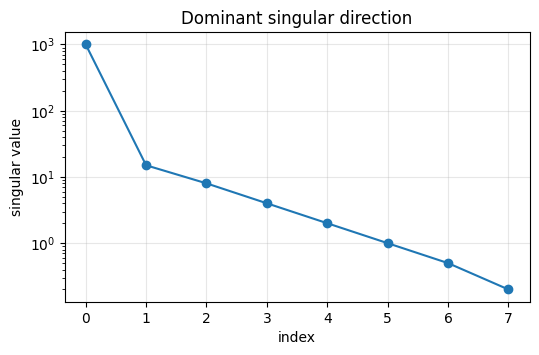

In [5]:
s=np.array([1000.,15.,8.,4.,2.,1.,.5,.2])
A=np.diag(s)
print(f'algebraic rank {np.linalg.matrix_rank(A)} stable rank {stable_rank(A)}')
plt.figure(figsize=(6,3.5))
plt.semilogy(s,marker='o')
plt.xlabel('index')
plt.ylabel('singular value')
plt.title('Dominant singular direction')
plt.grid(True,alpha=.3)
plt.show()

**ML numerics 自测**

**Q1.** SVD 把矩阵分解成了什么？

**A.** $A=U\Sigma V^T$。$U,V$ orthogonal，$\sigma_i$ 非负递减。$Av_i=\sigma_i u_i$：一组正交输入方向，各自只被缩放再旋转。

**Q2.** $\sigma_i$ 和 $A^TA$ 是什么关系？

**A.** $A^TA=V\Sigma^2V^T$，所以 $\sigma_i^2$ 是 $A^TA$ 的特征值。$\Vert Ax\Vert_2^2=x^TA^TAx$ 就是沿这些方向的能量增益。

**Q3.** $\kappa_2(A)$ 由哪两个量决定？

**A.** 可逆时 $\kappa_2(A)=\sigma_1/\sigma_n$。大 $\sigma_1$ 管 forward amplification，小 $\sigma_n$ 管 inverse sensitivity。

**Q4.** 某层出现 $\sigma_1\gg\sigma_2$ 意味着什么？

**A.** 可能是“单方向高增益”：representation 往一条方向塌，或该方向上的 precision perturbation 被大幅放大。


# Lecture 5 — More on the SVD

### 1. Pseudoinverse

若

$$
A=U\Sigma V^T,
$$

定义

$$
A^+=V\Sigma^+U^T,
\qquad
\Sigma^+_{ii}=\begin{cases}
1/\sigma_i,&\sigma_i>0,\\
0,&\sigma_i=0.
\end{cases}
$$

最关键的数值事实：**小 singular value 会在 inversion 中变成巨大 reciprocal**。

### 2. Best rank-k approximation

截断 SVD：

$$
A_k=U_k\Sigma_kV_k^T.
$$

Eckart–Young 结论。这里 $B$ 是被优化的自由变量，取遍与 $A$ 同形状、秩不超过 $k$ 的所有矩阵，即可行集 $\mathcal{B}_k=\{B\in\mathbb{R}^{m\times n}:\mathrm{rank}(B)\le k\}$：

$$
\Vert A-A_k\Vert_2=\min_{B\in\mathcal{B}_k}\Vert A-B\Vert_2=\sigma_{k+1},
$$

并且

$$
\Vert A-A_k\Vert_F^2=\min_{B\in\mathcal{B}_k}\Vert A-B\Vert_F^2=\sum_{i>k}\sigma_i^2.
$$

换句话说：无论用什么方式构造 rank-$k$ 逼近，误差都不可能小于截断 SVD，$A_k$ 本身就是这个最小化问题的最优解。若 $k\ge\mathrm{rank}(A)$ 则 $\sigma_{k+1}=0$；最优解唯一当且仅当 $\sigma_k>\sigma_{k+1}$（截断处有重奇异值时 $A_k$ 的取法不唯一，但最优误差值唯一）。该结论对任意 unitarily invariant norm 都成立，2-norm 和 Frobenius 只是两个常用特例。

这给出了低秩压缩能做到的最优线性误差边界。

### 3. Distance to rank deficiency

对 full-rank square matrix，最小 singular value 也是到 singular matrix 的 2-norm 距离：

$$
\min_{\Delta A:\,A+\Delta A\ \mathrm{singular}}\Vert \Delta A\Vert_2=\sigma_{\min}(A).
$$

所以 $\sigma_{\min}$ 直接量化“离失去可逆性还有多远”。

### 4. Deployment mapping

一个 $m\times n$ weight 若用 rank-$k$ 因子化：

$$
W\approx U_k\Sigma_kV_k^T,
$$

parameter cost 从 $mn$ 变成约 $k(m+n)$。但 latency 是否下降还取决于 GEMM shape、kernel launch、memory traffic 和 compiler fusion。

### 5. 陷阱：Eckart–Young 最优 $\ne$ 压缩最优

> **延伸，超出原书范围。** Trefethen & Bau 只讲到 Eckart–Young 本身；本节是把它接到实际的 model compression 上，属于自己加的 ML systems 映射。想只跟原书主线的话可以跳过。

Eckart–Young 的最优性是相对于 $\Vert A-B\Vert$ 这个**矩阵范数**说的。但压缩一个 layer 时，真正要控制的是 loss 的增量，一阶近似下是**输出误差**，而输出是否变化取决于权重误差落在哪些方向上——被输入激发得多的方向要紧，输入几乎不去的方向无所谓。

设该层为 $y=Wx$，输入二阶矩 $M=\mathbb{E}[xx^T]$。记**权重误差矩阵**

$$
\Delta_W:=W-\hat W\ \in\mathbb{R}^{m\times n},
$$

注意 $\Delta_W$ 是一个**矩阵**（下标 $W$ 提示它是 $W$ 的误差），所以 $\Delta_Wx$ 表示矩阵乘向量，不是“$x$ 的增量”。则压缩后的期望输出误差为

$$
\begin{aligned}
\mathbb{E}\big\Vert \Delta_Wx\big\Vert_2^2
&=\mathbb{E}\Big[\mathrm{tr}\big(\Delta_W\,xx^T\,\Delta_W^T\big)\Big]
&&\Vert v\Vert_2^2=v^Tv=\mathrm{tr}(vv^T),\ v=\Delta_Wx\\
&=\mathrm{tr}\big(\Delta_W\,\mathbb{E}[xx^T]\,\Delta_W^T\big)
&&\mathbb{E}\text{ 与 trace 均为线性算子，可交换}\\
&=\mathrm{tr}\big(\Delta_W\,SS^T\,\Delta_W^T\big)
&&M=\mathbb{E}[xx^T]=SS^T\\
&=\big\Vert \Delta_WS\big\Vert_F^2
&&\Vert A\Vert_F^2=\mathrm{tr}(AA^T),\ A=\Delta_WS
\end{aligned}
$$

这里 $M$ 对称半正定，故一定可以分解成 $M=SS^T$，$S$ 即 $M$ 的平方根因子（实现上一般取 Cholesky 因子）。

最后一步之所以成立，是因为 $A=\Delta_WS$ 的转置为 $A^T=S^T\Delta_W^T$，于是 $AA^T=\Delta_WSS^T\Delta_W^T$，正是上一行括号里的内容——$\Delta_W^T$ 并没有消失，只是被收进了 $A^T$ 的记号里。

所以要最小化的是 $\Vert (W-\hat W)S\Vert_F$ 而非 $\Vert W-\hat W\Vert_F$。这仍然能用 Eckart–Young 解，只是要先换元。分三步：

**(a) 把 $S$ 吸进去。** $S$ 是右乘，分配律直接成立：

$$
(W-\hat W)S=\underbrace{WS}_{\text{常数}}-\underbrace{\hat WS}_{\text{变量}},
$$

形式上已经是“常数矩阵减一个变量”，正是 Eckart–Young 要的样子。

**(b) 换元 $B=\hat WS$，且这是个双射。** 要把“对 $\hat W$ 优化”换成“对 $B$ 优化”，必须确认两个可行集一一对应，否则换元会改变问题。$S$ 可逆时：

- 正向：$\mathrm{rank}(\hat W)\le k\Rightarrow\mathrm{rank}(B)=\mathrm{rank}(\hat WS)=\mathrm{rank}(\hat W)\le k$（乘可逆矩阵不改变秩）；
- 反向：任给 $B\in\mathcal B_k$，取 $\hat W=BS^{-1}$，同理秩 $\le k$，且确实满足 $\hat WS=B$。

故两个问题等价：

$$
\min_{\mathrm{rank}(\hat W)\le k}\Vert WS-\hat WS\Vert_F=\min_{B\in\mathcal B_k}\Vert WS-B\Vert_F.
$$

$S$ 可逆是不能省的前提——否则反向映射不存在，$S^{-1}$ 也写不出来。

**(c) 套 Eckart–Young，再映射回去。** 右边就是标准的最佳低秩逼近，只不过被逼近的矩阵是 $WS$ 而非 $W$，故 $B^\star=(WS)_k$。用反向映射送回原变量：

$$
\hat W=(WS)_k\,S^{-1}
=\tilde U_k\tilde\Sigma_k\tilde V_k^TS^{-1},
\qquad WS=\tilde U\tilde\Sigma\tilde V^T.
$$

对应的最优目标值是 $\sqrt{\sum_{i>k}\tilde\sigma_i^2}$，其中 $\tilde\sigma_i$ 是 $WS$（不是 $W$）的奇异值。

这就是 activation-aware / whitened SVD（ASVD、SVD-LLM 等方法）的全部数学内容：**在被输入白化后的空间里做截断，再变换回来**。

**部署上 $S^{-1}$ 不产生运行时开销**，因为它可以吸收进右因子：

$$
\hat W=\underbrace{(\tilde U_k\tilde\Sigma_k)}_{m\times k}\underbrace{(\tilde V_k^TS^{-1})}_{k\times n}.
$$

导出时把 $\tilde V_k^TS^{-1}$ 算好存下来即可，参数量仍是 $k(m+n)$，推理时同样是两个 GEMM。$S$ 只活在离线压缩阶段，calibration 完就扔掉。

两个工程前提：

1. $M$ 实际是用少量 calibration data 估的，$\hat M=\frac{1}{N}XX^T$；
2. 上式要求 $S$ **可逆**，即 $M$ 严格正定。样本数不足或某些输入方向恒为零时 $\hat M$ 会奇异，所以实现中一般加 ridge：$\hat M+\lambda I$。这同时也压住了 $S^{-1}$ 那一步的误差放大——该步的条件数是 $\kappa(S)=\sqrt{\kappa(M)}$。

代价是 $\hat W$ 在权重 Frobenius 误差上必然**劣于** plain 截断 SVD——这不矛盾，正是 Eckart–Young 所保证的；我们只是换了一个更贴近任务的度量去最优化。

In [ ]:
m=n=256
Q1,_=np.linalg.qr(rng.normal(size=(m,48)))
Q2,_=np.linalg.qr(rng.normal(size=(n,48)))
sig=np.exp(-np.linspace(0,5,48))

# Main term is already in thin-SVD form (Q1, Q2 have orthonormal columns), so sig are exactly
# its singular values and its rank is 48. The trailing term is elementwise N(0,(1e-3)^2) noise
# that lifts W to full rank 256, modelling weights that are only approximately low rank.
# Caveat: entry scale != operator scale. The noise has sigma_max ~ 1e-3*(sqrt(m)+sqrt(n)) ~ 0.032,
# above the designed tail exp(-5) ~ 0.0067, so the spectrum tracks sig only up to index ~34 and
# then flattens into a noise plateau -- which is why rel_F_error stalls past k=32 below.
# Lower 1e-3 to 1e-5 to expose the full designed spectrum.
W=Q1@np.diag(sig)@Q2.T+1e-3*rng.normal(size=(m,n))
U,s,Vt=np.linalg.svd(W,full_matrices=False)
print(f' k   rel_F_error   ideal_param_compression')
for k in [4,8,16,32,64]:
    Wk=(U[:,:k]*s[:k])@Vt[:k]
    e=relerr(Wk,W)
    comp=(m*n)/(k*(m+n))
    print(f'{k:3d} {e:12.4e} {comp:10.2f}x')

 k   rel_F_error   ideal_param_compression
  4   6.5850e-01      32.00x
  8   4.3748e-01      16.00x
 16   2.0881e-01       8.00x
 32   1.0249e-01       4.00x
 64   7.5949e-02       2.00x


In [38]:
# plain truncated SVD vs activation-aware SVD:
# plain is optimal in weight error (Eckart-Young), activation-aware wins in output error
m=n=256
Q1,_=np.linalg.qr(rng.normal(size=(m,48)))
Q2,_=np.linalg.qr(rng.normal(size=(n,48)))
W=Q1@np.diag(np.exp(-np.linspace(0,5,48)))@Q2.T+1e-5*rng.normal(size=(m,n))

# anisotropic input distribution, deliberately misaligned with W's right singular vectors
Qc,_=np.linalg.qr(rng.normal(size=(n,n)))
sc=np.exp(-np.linspace(0,8,n))
M=(Qc*sc)@Qc.T
S=np.linalg.cholesky(0.5*(M+M.T)+1e-10*np.eye(n))
Sinv=np.linalg.inv(S)
X=(Qc*np.sqrt(sc))@rng.normal(size=(n,4096))

U,s,Vt=np.linalg.svd(W,full_matrices=False)
Ua,sa,Vta=np.linalg.svd(W@S,full_matrices=False)

def w_err(Wh):
    return np.linalg.norm(W-Wh,'fro')/np.linalg.norm(W,'fro')

def out_err(Wh):
    return np.linalg.norm((W-Wh)@X,'fro')/np.linalg.norm(W@X,'fro')

print(f"{'k':>3} {'plain_W':>11} {'aware_W':>11} {'plain_out':>11} {'aware_out':>11}")
for k in [4,8,16,32]:
    Wp=(U[:,:k]*s[:k])@Vt[:k]
    Wa=((Ua[:,:k]*sa[:k])@Vta[:k])@Sinv
    print(f'{k:3d} {w_err(Wp):11.3e} {w_err(Wa):11.3e} {out_err(Wp):11.3e} {out_err(Wa):11.3e}')

  k     plain_W     aware_W   plain_out   aware_out
  4   6.534e-01   6.864e-01   6.689e-01   6.437e-01
  8   4.269e-01   4.630e-01   4.449e-01   4.119e-01
 16   1.822e-01   2.011e-01   1.874e-01   1.653e-01
 32   3.268e-02   3.987e-02   3.204e-02   2.562e-02


**ML numerics 自测**

**Q1.** 伪逆里最危险的代数步骤是什么？

**A.** $\Sigma^+_{ii}=1/\sigma_i$（$\sigma_i>0$）。小 singular value 一取倒数就变成巨大增益。

**Q2.** 截断 SVD 的最优误差是多少？

**A.** Eckart–Young：$\min_{\mathrm{rank}(B)\le k}\Vert A-B\Vert_2=\sigma_{k+1}$，Frobenius 误差平方是 $\sum_{i>k}\sigma_i^2$。

**Q3.** $\sigma_{\min}$ 除了 inversion，还量化什么？

**A.** 到奇异矩阵的 2-norm 距离：$\min\Vert\Delta A\Vert_2=\sigma_{\min}(A)$。它告诉你离失去可逆性还有多远。

**Q4.** rank-$k$ 压缩省参数，就一定更快吗？

**A.** 参数从 $mn$ 变成约 $k(m+n)$。latency 还取决于 GEMM shape、kernel launch、memory traffic 和 fusion。


# Part II — QR Factorization and Least Squares

# Lecture 6 — Projectors

### 1. Orthogonal projector

若 $Q\in\mathbb{R}^{m\times k}$ 列正交，定义

$$
P=QQ^T.
$$

则

$$
P^2=QQ^TQQ^T=QQ^T=P,
\qquad P^T=P.
$$

对任意 $x$，

$$
x=\underbrace{Px}_{\text{projection}}+\underbrace{(I-P)x}_{\text{residual }r}.
$$

$Px$ 是 $x$ 落在 $\mathcal R(Q)$ 内的分量，**residual $r=(I-P)x$ 就是投影之后剩下的那一部分**。这个命名借自 least squares（见第 2 节）：那里 $r=b-A\hat x=(I-P)b$ 正是标准的残差向量。

它与子空间正交，展开只需要用 $Q^TQ=I_k$：

$$
Q^T(I-P)x=Q^Tx-Q^T\underbrace{QQ^T}_{P}x=Q^Tx-\underbrace{(Q^TQ)}_{I_k}Q^Tx=0.
$$

$Q^Tr=0$ 表示 $r$ 与 $Q$ 每一列都内积为零，而这些列张成 $\mathcal R(Q)$，所以 residual 正交于子空间 $\mathcal R(Q)$，即 $r\in\mathcal R(Q)^\perp$。

顺带，$I-P$ 自己也是正交 projector（投到 $\mathcal R(Q)^\perp$）：$(I-P)^2=I-2P+P^2=I-P$，且 $(I-P)^T=I-P$。于是上面的分解是把空间劈成两个互相正交的部分，勾股定理成立：

$$
\Vert x\Vert_2^2=\Vert Px\Vert_2^2+\Vert (I-P)x\Vert_2^2.
$$

**数值警告**：$Q^Tr=0$ 只在精确算术下成立。浮点下 classical Gram–Schmidt 会丢失正交性，$\Vert Q^TQ-I\Vert$ 可涨到 $O(\varepsilon\,\kappa(A)^2)$，算出的 residual 并不真正垂直于子空间。这正是后面要用 Householder QR 的理由：正交性由构造（正交变换之积）保证，误差只到 $O(\varepsilon)$，与 $\kappa(A)$ 无关。

### 2. 为什么 projector 是 least squares 的几何核心

寻找 $\mathcal R(A)$ 中离 $b$ 最近的点，就是找 projection：

$$
\hat b=Pb.
$$

如果 $A=QR$，那么 column space 不变：$\mathcal R(A)=\mathcal R(Q)$，所以 projector 直接是 $QQ^T$。

### 3. Representation mapping

比较两个 checkpoint 时，raw basis vector 可能因为任意 rotation 看起来差很大。更稳定的对象往往是 projector：

$$
P_1=Q_1Q_1^T,\qquad P_2=Q_2Q_2^T.
$$

$\Vert P_1-P_2\Vert$ 描述的是 subspace 是否真的改变，而不是坐标系是否旋转。

In [7]:
Q,_=np.linalg.qr(rng.normal(size=(40,6)))
P=Q@Q.T
x=rng.normal(size=40)
a=P@x
b=(np.eye(40)-P)@x
print(f'P^2-P {np.linalg.norm(P @ P - P)} parallel dot perp {a @ b}')

P^2-P 1.0060413183053655e-15 parallel dot perp 6.891191880169215e-17


**ML numerics 自测**

**Q1.** 正交投影 $P=QQ^T$ 满足什么？

**A.** $P^2=P$、$P^T=P$。$x=Px+(I-P)x$，且 residual $(I-P)x$ 正交于 $\mathcal{R}(Q)$。

**Q2.** 它和 least squares 是什么几何关系？

**A.** 在 $\mathcal{R}(A)$ 里找离 $b$ 最近的点就是 $\hat b=Pb$。若 $A=QR$，则 $P=QQ^T$。

**Q3.** 比较两个 checkpoint 的 basis，为什么不该直接比 $Q$？

**A.** $Q$ 可以任意旋转。该比 projector：$\Vert P_1-P_2\Vert$ 说的是 subspace 变没变，不是坐标系转没转。

**Q4.** ML 里什么时候该用 $P$ 而不是 raw activation basis？

**A.** representation drift / subspace stability。把旋转误判成 drift，是常见的假阳性。


# Lecture 7 — QR Factorization

### 1. QR factorization

对 full-column-rank $A\in\mathbb{R}^{m\times n}$（$m\ge n$），

$$
A=QR,
$$

其中

$$
Q^TQ=I,\qquad R\ \text{upper triangular}.
$$

几何上，$Q$ 给出 column space 的 orthonormal basis；$R$ 记录原始 columns 在这个 basis 下的坐标。

### 2. QR 与 least squares

$$
\min_x\Vert Ax-b\Vert_2
=\min_x\Vert QRx-b\Vert_2.
$$

将 $b$ 分解为 $QQ^Tb+(I-QQ^T)b$：

$$
\Vert QRx-b\Vert_2^2
=\Vert Rx-Q^Tb\Vert_2^2+\Vert(I-QQ^T)b\Vert_2^2.
$$

第二项与 $x$ 无关，因此 optimum 满足

$$
Rx=Q^Tb.
$$

这就是 QR least squares。

### 3. Numerical point

QR 本身可以非常 stable，即使 $A$ condition number 很大。要区分：

- factorization 是否 accurate；
- 后续 inverse/least-squares problem 是否 well-conditioned。

**ML numerics 自测**

**Q1.** QR 在几何上分别给出什么？

**A.** $A=QR$：$Q$ 是 column space 的 orthonormal basis，$R$ 是原 columns 在这个 basis 下的坐标。

**Q2.** QR least squares 最后解的是哪个方程？

**A.** $\Vert QRx-b\Vert_2^2=\Vert Rx-Q^Tb\Vert_2^2+\Vert(I-QQ^T)b\Vert_2^2$。第二项与 $x$ 无关，所以 $Rx=Q^Tb$。

**Q3.** QR factorization stable，least squares 就一定准吗？

**A.** 不一定。QR 可以准确地揭示 $A$ 很病态；$R$ 对角很小之后，solve 仍然 sensitive。

**Q4.** 该把“分解准”和“问题好条件”哪件事分开？

**A.** factorization accuracy vs subsequent inverse / least-squares conditioning。两者不是一回事。


# Lecture 8 — Gram-Schmidt Orthogonalization

### 1. Classical Gram–Schmidt

第 $j$ 个 column：

$$
r_{ij}=q_i^Ta_j,
\qquad
v_j=a_j-\sum_{i<j}r_{ij}q_i,
\qquad
q_j=\frac{v_j}{\Vert v_j\Vert}.
$$

### 2. Modified Gram–Schmidt

MGS 把 projection 一次一次从当前 residual 中减掉：

$$
v_j^{(i+1)}=v_j^{(i)}-q_i(q_i^Tv_j^{(i)}).
$$

Exact arithmetic 下 CGS=MGS；floating point 下不是。

### 3. 为什么 CGS 容易失去 orthogonality

当 $a_j$ 已经几乎在 span$(q_1,\ldots,q_{j-1})$ 中，

$$
a_j\approx\sum_i r_{ij}q_i.
$$

计算 residual 相当于“大数减大数得到很小的数”，产生 catastrophic cancellation。残余 rounding error 与真正的新方向可能同量级，于是新 $q_j$ 不再正交。

### 4. ML mapping

- gradient subspace / activation basis；
- Arnoldi basis；
- PCA/low-rank online basis。

如果你看到“新方向”越来越不像新方向，先检查 orthogonality error：

$$
\Vert Q^TQ-I\Vert.
$$


In [8]:
def cgs(A):
    m,n=A.shape
    Q=np.zeros((m,n))
    R=np.zeros((n,n))
    for j in range(n):
        v=A[:,j].copy()
        if j:
            R[:j,j]=Q[:,:j].T@A[:,j]
            v=A[:,j]-Q[:,:j]@R[:j,j]
        R[j,j]=np.linalg.norm(v)
        Q[:,j]=v/R[j,j]
    return Q,R

def mgs(A):
    V=A.copy()
    m,n=A.shape
    Q=np.zeros((m,n))
    R=np.zeros((n,n))
    for i in range(n):
        R[i,i]=np.linalg.norm(V[:,i])
        Q[:,i]=V[:,i]/R[i,i]
        for j in range(i+1,n):
            R[i,j]=Q[:,i]@V[:,j]
            V[:,j]-=R[i,j]*Q[:,i]
    return Q,R

t=np.linspace(.98,1.02,100)
A=np.vstack([t**j for j in range(20)]).T
Qc,_=cgs(A)
Qm,_=mgs(A)
Qh,_=np.linalg.qr(A)
I=np.eye(20)
print(f'cond {np.linalg.cond(A)}')
print(f'CGS {np.linalg.norm(Qc.T @ Qc - I)}')
print(f'MGS {np.linalg.norm(Qm.T @ Qm - I)}')
print(f'Householder {np.linalg.norm(Qh.T @ Qh - I)}')

cond 1.401305623443951e+17
CGS 15.50719421204065
MGS 1.6563693481879005
Householder 2.34334261584103e-15


**ML numerics 自测**

**Q1.** CGS 和 MGS 在 exact arithmetic 下一样吗？

**A.** 一样。floating point 下不一样：MGS 把投影一次次从当前 residual 里减掉，通常更能保住 orthogonality。

**Q2.** CGS 为什么容易丢掉 orthogonality？

**A.** 当 $a_j$ 已几乎在旧 span 里，residual 是大数减大数。cancellation 后，rounding 和真正的新方向同量级。

**Q3.** 最该监控的诊断量是什么？

**A.** $\Vert Q^TQ-I\Vert$。看到“新方向”不像新方向，先查这个。

**Q4.** ML 里哪些地方会踩到同一问题？

**A.** gradient / activation basis、Arnoldi、在线 PCA。病态的是 cancellation，不是“正交这个概念”。


# Lecture 9 — MATLAB → NumPy/PyTorch Numerical Computing

### 1. 原书 MATLAB lecture 在今天对应什么

这里不把重点放在 Python syntax，而是放在**正确调用 numerical kernels**。

优先写：

$$
Ax=b\quad\Rightarrow\quad x=\mathrm{solve}(A,b)
$$

而不是

$$
x=A^{-1}b.
$$

因为显式 inverse：

1. 多做工作；
2. 产生额外 rounding；
3. 丢失 solver 对结构（triangular/SPD）的利用。

### 2. Vectorization 不是只有“快”

`A @ x`, `qr`, `svd`, `lstsq` 背后通常调用成熟 BLAS/LAPACK，这些实现不仅更快，也经过多年数值稳定性设计。

### 3. 编译时代的新问题

PyTorch/Inductor/TensorRT 等 compiler 可能做：

- reassociation；
- fusion；
- precision lowering；
- constant folding；
- kernel substitution。

这些都可能改变 floating-point program。

所以 parity 的正确问题不是“graph mathematically equivalent 吗”，而是：

$$
\text{local numerical perturbation}\times\text{downstream sensitivity}
$$

是否仍在 error budget 内。

In [9]:
A=make_cond(80,1e7,1)
b=rng.normal(size=80)
xs=np.linalg.solve(A,b)
xi=np.linalg.inv(A)@b
print(f'solve residual {relerr(A @ xs, b)}')
print(f'inv@b residual {relerr(A @ xi, b)}')
print(f'solution difference {relerr(xi, xs)}')

solve residual 6.799142404775882e-11
inv@b residual 1.1750344190239224e-10
solution difference 5.618917679728512e-15


**ML numerics 自测**

**Q1.** 为什么不要写 $x=A^{-1}b$，而要 $\mathrm{solve}(A,b)$？

**A.** 显式 inverse 更多工作、更多 rounding，还丢掉 triangular/SPD 等结构。成熟 solver 就是为这个设计的。

**Q2.** vectorized kernel 除了快，还带来什么？

**A.** `@` / `qr` / `svd` / `lstsq` 背后是 BLAS/LAPACK，数值稳定性也经过多年打磨。

**Q3.** compiler 把 graph 变“代数等价”，parity 就该过吗？

**A.** 不该。reassociation、fusion、precision lowering 会改变浮点程序。该问的是 local perturbation $\times$ downstream sensitivity 是否仍在 budget 内。

**Q4.** deployment 里正确的问题是什么？

**A.** 不是 “graph mathematically equivalent 吗”，而是数值扰动传到 task output 后还能否接受。


# Lecture 10 — Householder Triangularization

### 1. Householder reflector

给定非零 $v$，标准形式

$$
H=I-2\frac{vv^T}{v^Tv}.
$$

可验证

$$
H^T=H,
\qquad
H^TH=I,
\qquad
H^2=I.
$$

所以它是一个 orthogonal reflection。

### 2. 如何把一个向量变成 $\pm\Vert x\Vert e_1$

目标是选择 $v$，使

$$
Hx=\alpha e_1,
\qquad |\alpha|=\Vert x\Vert_2.
$$

常取

$$
\alpha=-\operatorname{sign}(x_1)\Vert x\Vert_2,
\qquad
v=x-\alpha e_1.
$$

关键是负号选择：若 $x_1>0$，不去计算 $x_1-\Vert x\Vert$ 这种可能非常小的 cancellation，而使用 $x_1+\Vert x\Vert$。

### 3. QR triangularization

依次作用 Householder：

$$
H_n\cdots H_2H_1A=R.
$$

于是

$$
A=Q R,
\qquad
Q=H_1H_2\cdots H_n.
$$

### 4. Numerical lesson

Householder 的强项不是“数学上能做 QR”，而是可以用一系列 norm-preserving transformations 做到 backward stable QR。

In [10]:
x=rng.normal(size=8)
e1=np.zeros_like(x)
e1[0]=1
alpha=-np.sign(x[0] if x[0]!=0 else 1)*np.linalg.norm(x)
v=x-alpha*e1
v/=np.linalg.norm(v)
H=np.eye(8)-2*np.outer(v,v)
y=H@x
print(f'tail after reflection {np.linalg.norm(y[1:])}')
print(f'orthogonality {np.linalg.norm(H.T @ H - np.eye(8))}')

tail after reflection 4.83984740964111e-16
orthogonality 5.166739843304062e-16


**ML numerics 自测**

**Q1.** Householder $H=I-2vv^T/v^Tv$ 有什么结构？

**A.** $H^T=H$、$H^TH=I$、$H^2=I$：它是正交反射，因此 norm-preserving。

**Q2.** 选 $v$ 时最危险的中间量是什么？

**A.** 若 $x_1>0$，不要算 $x_1-\Vert x\Vert$ 这种可能极小的差。用 $\alpha=-\mathrm{sign}(x_1)\Vert x\Vert_2$，走 $x_1+\Vert x\Vert$，躲开 cancellation。

**Q3.** Householder QR 强在“能做 QR”，还是强在稳定？

**A.** 强在用一串 norm-preserving 变换做出 backward stable QR，而不是仅仅数学上能三角化。

**Q4.** 一串 $H_k$ 为什么不会把前面的误差指数放大？

**A.** 每一步 $\Vert H_k\Vert_2=1$。perturbation 在后续正交变换里不会被越乘越大。


# Lecture 11 — Least Squares Problems

### 1. Least squares 的几何

当 $m>n$ 时，通常不存在 $Ax=b$ 的精确解。我们求

$$
x_*=\arg\min_x\Vert Ax-b\Vert_2.
$$

令 residual

$$
r=b-Ax_*.
$$

最优时 residual 必须与 column space 正交：

$$
A^Tr=0.
$$

因此

$$
A^TAx_*=A^Tb,
$$

即 normal equations。

### 2. 为什么 QR 更自然

若 $A=QR$，

$$
\Vert Ax-b\Vert^2
=\Vert Rx-Q^Tb\Vert^2+\Vert(I-QQ^T)b\Vert^2.
$$

所以直接解

$$
Rx=Q^Tb.
$$

避免显式构造 $A^TA$。

### 3. ML example：linear probe

假设 $A$ 是 frozen embedding matrix，$b$ 是 target。若 embedding columns 高度相关，可能出现：

- prediction $Ax$ 很稳定；
- parameter $x$ checkpoint-to-checkpoint 差异很大。

这不是矛盾，而是 near-null directions 中的 parameter non-identifiability。

In [11]:
A=rng.normal(size=(400,12))
xt=rng.normal(size=12)
b=A@xt+.05*rng.normal(size=400)
x,*_=np.linalg.lstsq(A,b,rcond=None)
r=b-A@x
print(f'||A^T r|| {np.linalg.norm(A.T @ r)} parameter error {relerr(x, xt)}')

||A^T r|| 1.3320492599601637e-12 parameter error 0.0029393932348581293


**ML numerics 自测**

**Q1.** least squares 最优时 residual 满足什么？

**A.** $x_*=\arg\min\Vert Ax-b\Vert_2$。最优则 $A^Tr=0$，即 $r$ 正交于 column space，也就是 normal equations $A^TAx_*=A^Tb$。

**Q2.** 为什么 QR 比显式 $A^TA$ 更自然？

**A.** $A=QR$ 时直接解 $Rx=Q^Tb$，避开构造 $A^TA$（后者把 $\kappa$ 平方）。

**Q3.** linear probe 里 $Ax$ 很稳、$x$ 却乱跳，矛盾吗？

**A.** 不矛盾。near-null directions 上参数不可辨识：预测可以稳，parameter 可以差很多。

**Q4.** 该同时看哪两类量？

**A.** prediction / residual stability，以及 representation / parameter identifiability。只看 loss 会漏掉后者。


# Part III — Conditioning and Stability

# Lecture 12 — Conditioning and Condition Numbers

### 1. Conditioning 是函数的局部 sensitivity

把问题写成 $y=f(x)$。局部绝对 condition number 可理解为 Jacobian norm：

$$
\kappa_{\mathrm{abs}}(x)=\Vert Df(x)\Vert.
$$

相对 condition number 则把输入输出 scale 加进去。

### 2. Linear solve 的一阶 perturbation

$$
Ax=b.
$$

扰动后

$$
(A+\Delta A)(x+\Delta x)=b+\Delta b.
$$

忽略二阶项 $\Delta A\Delta x$：

$$
A\Delta x\approx\Delta b-\Delta A x,
$$

于是

$$
\Delta x\approx A^{-1}(\Delta b-\Delta A x).
$$

取 norm：

$$
\frac{\Vert \Delta x\Vert}{\Vert x\Vert}
\lesssim
\kappa(A)
\left(
\frac{\Vert \Delta A\Vert}{\Vert A\Vert}
+
\frac{\Vert \Delta b\Vert}{\Vert b\Vert}
\right).
$$

这就是 condition number 的工程意义：input perturbation 的相对误差可能被 $\kappa(A)$ 放大。

### 3. SVD interpretation

$$
\Vert A^{-1}\Vert_2=1/\sigma_{\min}(A),
$$

所以最危险的是 near-null direction。

### 4. ML mapping

欠约束的 representation、近冗余 feature、flat Hessian directions，本质上都在制造小 singular/eigen directions。

In [12]:
A=make_cond(30,1e8,10)
xt=rng.normal(size=30)
b=A@xt
x0=np.linalg.solve(A,b)
db=rng.normal(size=30)
db*=1e-8*np.linalg.norm(b)/np.linalg.norm(db)
x1=np.linalg.solve(A,b+db)
rb=np.linalg.norm(db)/np.linalg.norm(b)
rx=relerr(x1,x0)
print(f'cond {np.linalg.cond(A)} relative b perturbation {rb} relative x change {rx} amplification {rx / rb}')

cond 100000000.04838386 relative b perturbation 1.0000000000000002e-08 relative x change 0.016511927077851218 amplification 1651192.7077851214


**ML numerics 自测**

**Q1.** condition number 本质在量什么？

**A.** 问题 $y=f(x)$ 的局部灵敏度。绝对条件数是 $\Vert Df(x)\Vert$；相对条件数再把输入输出 scale 算进去。

**Q2.** 线性方程组里 $\kappa(A)$ 怎么进 bound？

**A.** $\Vert\Delta x\Vert/\Vert x\Vert\lesssim\kappa(A)\,(\Vert\Delta A\Vert/\Vert A\Vert+\Vert\Delta b\Vert/\Vert b\Vert)$。相对输入误差最多被 $\kappa$ 放大。

**Q3.** SVD 下最危险的方向是哪条？

**A.** $\Vert A^{-1}\Vert_2=1/\sigma_{\min}$，near-null direction。欠约束 feature / flat Hessian 都在制造这种方向。

**Q4.** 监控 $\kappa$ 是在监控算法，还是监控问题？

**A.** 监控问题本身。算法再 stable，也只能保证 backward error 是 $O(u)$；forward error 仍可到 $\kappa u$。


# Lecture 13 — Floating Point Arithmetic

### 1. Floating-point model

一个 normalized floating-point number 可以抽象为

$$
x=\pm(1.b_1b_2\ldots b_p)_2\,2^e.
$$

有限 mantissa 意味着相邻 representable numbers 间距随 scale 变化。

通常用 unit roundoff $u$ 表示一次正确 rounding 的相对误差规模。对一个已经算出来的实数做舍入：

$$
\mathrm{fl}(x)=x(1+\delta),\qquad |\delta|\le u.
$$

对一次精确算术运算，标准模型写成

$$
\mathrm{fl}(a\circ b)=(a\circ b)(1+\delta),\qquad |\delta|\lesssim u.
$$

$\mathrm{fl}(\cdot)$ 是机器实际写出的数，$a\circ b$ 是精确加减乘除，$\delta$ 是这次运算的相对误差。约束的是相对误差，不是绝对误差。

常见 $u$：FP32 $\approx 6\times 10^{-8}$，FP16 $\approx 5\times 10^{-4}$，BF16 $\approx 4\times 10^{-3}$。一次运算只引入 $u$；若问题的 $\kappa$ 很大，解的 forward error 可以到 $\kappa u$ 量级。算法 stable 只保证「没有把 rounding 额外放大」，不保证病态问题仍有精确解。

### 2. Catastrophic cancellation

若 $x\approx y$，计算

$$
z=x-y
$$

时，输入本身的微小相对误差可能在小 residual 中占很大比例。

例如本来有

$$
x=1.0000001,\quad y=1.0000000,
$$

差值只有 $10^{-7}$。如果低精度根本无法分辨这两个数，结果直接变成 0。

### 3. BF16 vs FP16 的不同风险

- FP16：mantissa 相对多，但 exponent range 小，容易 overflow/underflow；
- BF16：exponent 类似 FP32，但 mantissa 很粗，容易丢掉小 relative differences。

### 4. ML high-risk operations

- long reduction；
- variance / RMSNorm statistics；
- softmax logits；
- reciprocal / sqrt；
- Gram matrices；
- small-pivot factorization。

In [13]:
for dt in [np.float16,np.float32,np.float64]:
    f=np.finfo(dt)
    print(f'{dt.__name__} eps {f.eps} tiny {f.tiny} max {f.max}')

float16 eps 0.000977 tiny 6.104e-05 max 6.55e+04
float32 eps 1.1920929e-07 tiny 1.1754944e-38 max 3.4028235e+38
float64 eps 2.220446049250313e-16 tiny 2.2250738585072014e-308 max 1.7976931348623157e+308


**ML numerics 自测**

**Q1.** $\mathrm{fl}(a\circ b)=(a\circ b)(1+\delta)$ 约束的是什么？

**A.** 一次运算的相对误差 $|\delta|\lesssim u$，不是绝对误差。$u$：FP32 $\approx 6\times 10^{-8}$，FP16 $\approx 5\times 10^{-4}$，BF16 $\approx 4\times 10^{-3}$。

**Q2.** 什么时候相对误差模型会突然崩？

**A.** catastrophic cancellation：$x\approx y$ 时 $x-y$ 把已有误差抬成主导项。低精度甚至根本分不出 $1.0000001$ 和 $1$。

**Q3.** BF16 和 FP16 的风险有何不同？

**A.** FP16 mantissa 较多但 exponent 窄，怕 overflow/underflow；BF16 exponent 像 FP32，但 mantissa 粗，怕丢掉小相对差。

**Q4.** ML 里哪些 op 最吃 $u$？

**A.** 长 reduction、RMSNorm/variance、softmax、reciprocal/sqrt、Gram、$A^TA$、小 pivot 分解。


# Lecture 14 — Stability

### 1. Forward error

算法输出 $\hat y$，真正答案 $y=f(x)$：

$$
\text{forward error}=\Vert \hat y-y\Vert.
$$

### 2. Backward error

找最小 $\Delta x$，使

$$
\hat y=f(x+\Delta x).
$$

如果所需 $\Delta x$ 与 machine precision 同量级，我们说算法 backward stable。

### 3. Residual 不是 forward error

对 linear solve，

$$
r=b-A\hat x.
$$

因为

$$
A(x-\hat x)=r,
$$

所以

$$
x-\hat x=A^{-1}r.
$$

因此

$$
\Vert x-\hat x\Vert \le \Vert A^{-1}\Vert \Vert r\Vert.
$$

如果 $A^{-1}$ 很大，小 residual 仍然可能对应大 solution error。

### 4. Deployment parity mapping

只看 tensor residual/output diff 不够。至少要知道：

- local error 多大；
- downstream operator gain 多大；
- task output 对该方向 sensitivity 多大。

In [14]:
A=make_cond(25,1e12,12)
xt=rng.normal(size=25)
b=A@xt
x=np.linalg.solve(A,b)
print(f'relative residual {relerr(A @ x, b)}')
print(f'forward error {relerr(x, xt)}')
print(f'cond {np.linalg.cond(A)}')

relative residual 1.39684738700378e-16
forward error 5.386772903402778e-06
cond 999992300445.1638


**ML numerics 自测**

**Q1.** forward error 和 backward error 各是什么？

**A.** forward：$\Vert\hat y-y\Vert$，答案错多少。backward：最小 $\Delta x$ 使 $\hat y=f(x+\Delta x)$。$\Delta x$ 与 $u$ 同量级就称 backward stable。

**Q2.** 为什么 residual 不是 forward error？

**A.** $r=b-A\hat x$ 时 $x-\hat x=A^{-1}r$，故 $\Vert x-\hat x\Vert\le\Vert A^{-1}\Vert\Vert r\Vert$。$A^{-1}$ 大时，小 residual 仍可对应大解误差。

**Q3.** 只看 output tensor diff 够不够做 deployment parity？

**A.** 不够。还要看 local error、downstream gain、以及 task 对该方向的 sensitivity。

**Q4.** stable 算法保证的是哪一种 error？

**A.** 保证的是小 backward error，不是小 forward error。


# Lecture 15 — More on Stability

### 1. “Backward stable + well-conditioned = accurate”

这是 numerical analysis 最重要的组合关系之一。

若算法 backward stable，意味着它实际上求解的是 nearby problem：

$$
\hat y=f(x+\Delta x),
\qquad
\frac{\Vert \Delta x\Vert}{\Vert x\Vert}=O(u).
$$

若问题的 relative condition number 为 $\kappa$，则一阶近似：

$$
\frac{\Vert \hat y-y\Vert}{\Vert y\Vert}
=O(\kappa u).
$$

所以误差可以拆成：

$$
\boxed{\text{problem sensitivity}}
\times
\boxed{\text{algorithm perturbation}}.
$$

### 2. 为什么这个分解适合 mixed precision

假设某个 kernel 引入局部 perturbation $\epsilon$，下游 Jacobian gain 为 $G$：

$$
\delta y\approx G\epsilon.
$$

这就是现代版的 condition × backward error 思维。

### 3. 一个有用的 sanity scale

若 FP32 $u\sim10^{-7}$，而 $\kappa\sim10^8$，那么 $\kappa u$ 已经接近 10。此时“算法很 stable”也不能保证 forward answer 有意义。

**ML numerics 自测**

**Q1.** “backward stable + well-conditioned = accurate” 怎么拆？

**A.** 算法给出 nearby problem：$\Vert\Delta x\Vert/\Vert x\Vert=O(u)$。问题相对条件数为 $\kappa$，则 $\Vert\hat y-y\Vert/\Vert y\Vert=O(\kappa u)$。

**Q2.** mixed precision 里这句话变成什么？

**A.** kernel 引入局部扰动 $\epsilon$，下游 Jacobian gain 为 $G$，则 $\delta y\approx G\epsilon$。仍是 condition $\times$ backward error。

**Q3.** FP32、$u\sim 10^{-7}$、$\kappa\sim 10^8$ 说明什么？

**A.** $\kappa u$ 已接近 10。“算法很 stable”也不能保证 forward answer 有意义。

**Q4.** 该分别报告哪两个盒子？

**A.** problem sensitivity 和 algorithm perturbation。混成一句“数值不稳”会选错修法。


# Lecture 16 — Stability of Householder Triangularization

### 1. Householder QR 的 backward stability 结论

设 floating-point 算法计算出 $\hat Q,\hat R$。核心结论可理解为存在一个很小的 $\Delta A$，使

$$
A+\Delta A=\hat Q\hat R,
\qquad
\frac{\Vert \Delta A\Vert}{\Vert A\Vert}=O(u)
$$

（更精确的 bound 还含维度常数）。

也就是说算法没有把 rounding error 变成一个远离原输入的问题。

### 2. 为什么 orthogonal transformations 有优势

每一步 reflector $H_k$ 的 norm 是 1：

$$
\Vert H_k\Vert_2=1.
$$

所以前面某一步产生的 perturbation 在后续正交变换中不会被指数放大。

### 3. 但 QR stable ≠ least squares 一定 accurate

如果 $A$ 接近 rank deficient，$R$ 的 diagonal 会出现极小值。QR 可能准确地揭示这个坏条件数，但 solve 本身仍然 sensitive。

**ML numerics 自测**

**Q1.** Householder QR 的 backward stability 结论是什么？

**A.** 存在 $\Delta A$ 使 $A+\Delta A=\hat Q\hat R$，且 $\Vert\Delta A\Vert/\Vert A\Vert=O(u)$。算法没有把 rounding 变成远离原问题的另一个问题。

**Q2.** 为什么正交变换帮得上忙？

**A.** 每步 $\Vert H_k\Vert_2=1$，前面的 perturbation 不会在后续反射里被指数放大。

**Q3.** QR stable 是否等于 least squares accurate？

**A.** 不等于。$A$ 接近亏秩时 $R$ 对角会出现极小值。QR 可能准确地报告坏条件，solve 仍然敏感。

**Q4.** 该监控 $\Vert\Delta A\Vert$ 还是 $\Vert\hat x-x\Vert$？

**A.** 先看 backward residual / $\Vert A-\hat Q\hat R\Vert$ 判断分解；再单独看 $\kappa(R)$ 判断后续 solve。


# Lecture 17 — Stability of Back Substitution

### 1. Back substitution

对 upper triangular $R$：

$$
Rx=b.
$$

最后一行先得到

$$
x_n=b_n/r_{nn},
$$

然后递推

$$
x_i=\frac{1}{r_{ii}}
\left(b_i-\sum_{j=i+1}^nr_{ij}x_j\right).
$$

### 2. Numerical risk

两个地方最敏感：

1. $r_{ii}$ 很小：division 放大误差；
2. 括号中的 subtraction cancellation。

对一个 backward-stable triangular solver，可以把计算结果解释为

$$
(R+\Delta R)\hat x=b,
\qquad
|\Delta R|\lesssim O(u)|R|.
$$

但如果 $R$ condition number 大，forward error 依旧可能很大。

### 3. ML mapping

Cholesky/QR/LU 最终都落到 triangular solve，因此“factorization 成功”不代表整个 solve 已经安全。

In [15]:
n=12
R=np.triu(rng.normal(size=(n,n)))
np.fill_diagonal(R,np.geomspace(1,1e-7,n))
xt=rng.normal(size=n)
b=R@xt
x32=np.linalg.solve(R.astype(np.float32),b.astype(np.float32)).astype(float)
print(f'cond(R) {np.linalg.cond(R)} FP32 forward error {relerr(x32, xt)} residual {relerr(R @ x32, b)}')

cond(R) 2.165313245317661e+24 FP32 forward error 1.5518121342003009e+22 residual 40001657452468.914


**ML numerics 自测**

**Q1.** 回代 $Rx=b$ 哪两步最危险？

**A.** $x_n=b_n/r_{nn}$：小 $r_{ii}$ 的除法放大误差；括号里 $b_i-\sum r_{ij}x_j$ 的 subtraction cancellation。

**Q2.** backward-stable triangular solve 实际在解什么？

**A.** $(R+\Delta R)\hat x=b$，且 $|\Delta R|\lesssim O(u)|R|$。$R$ 的 $\kappa$ 大时 forward error 仍可很大。

**Q3.** factorization 成功是否等于整个 solve 安全？

**A.** 不等于。Cholesky/QR/LU 最后都落到 triangular solve。分解成功只走完前半段。

**Q4.** ML 小系统 solve 该盯哪个量？

**A.** $|r_{ii}|$、$\kappa(R)$、residual，以及相对 FP64 的 forward error。


# Lecture 18 — Conditioning of Least Squares Problems

### 1. Least squares conditioning 比 square solve 更丰富

$$
x_*=(A^TA)^{-1}A^Tb=A^+b
$$

（full column rank）。如果 $\sigma_{\min}(A)$ 很小，$A^+$ norm 很大：

$$
\Vert A^+\Vert_2=1/\sigma_{\min}(A).
$$

### 2. Residual angle

令 fitted vector $p=Ax_*$，residual $r=b-p$。当 $b$ 几乎 orthogonal to column space 时，$p$ 很小而 residual 很大，relative parameter sensitivity 也会恶化。

因此 least-squares conditioning 不仅取决于 $\kappa(A)$，还取决于 $b$ 与 $\mathcal R(A)$ 的几何关系。

### 3. ML interpretation

对于 linear probe，如果 target 大部分不在 embedding span 中：

- residual 大；
- weak singular directions 决定的 coefficient 会非常不稳定；
- 不同 checkpoint 可以得到类似 prediction loss，却有截然不同的 parameter vector。

这就是为什么要同时看 prediction stability 和 representation/parameter identifiability。

**ML numerics 自测**

**Q1.** least squares 的 $\Vert A^+\Vert$ 由什么决定？

**A.** full column rank 时 $x_*=A^+b$，$\Vert A^+\Vert_2=1/\sigma_{\min}(A)$。小 $\sigma_{\min}$ 让参数对扰动极敏感。

**Q2.** conditioning 是否只取决于 $\kappa(A)$？

**A.** 不只。还取决于 $b$ 与 $\mathcal{R}(A)$ 的夹角：residual 大、$p=Ax_*$ 小时，相对参数灵敏度更差。

**Q3.** linear probe 为何能 loss 相近、参数却完全不同？

**A.** target 大部分不在 embedding span 里时，弱 singular 方向上的系数不稳定。预测可以像，parameter 可以不像。

**Q4.** 该同时报哪两个稳定性？

**A.** prediction stability 和 parameter / representation identifiability。


# Lecture 19 — Stability of Least Squares Algorithms

### 1. Normal equations 为什么危险

$$
A^TAx=A^Tb.
$$

SVD：

$$
A=U\Sigma V^T
\Rightarrow
A^TA=V\Sigma^2V^T.
$$

因此

$$
\kappa_2(A^TA)
=\frac{\sigma_1^2}{\sigma_n^2}
=\kappa_2(A)^2.
$$

这不是小常数差异，而是**把 condition number 平方**。

### 2. 三种常见路线

**Normal equations**

$$
A^TAx=A^Tb
$$

便宜、结构简单，但失去精度。

**QR**

$$
A=QR,\qquad Rx=Q^Tb
$$

通常是 dense least squares 的稳定默认。

**SVD**

$$
x=V\Sigma^+U^Tb
$$

最能处理 rank deficiency，也最贵。

### 3. 工程判断

如果你是在做 calibration / fitting，并且 feature covariance spectrum 很差，不要只因为 $A^TA$ 容易写就默认 normal equations。

In [16]:
m,n=120,12
z=rng.normal(size=(m,1))
A=np.hstack([z+10**(-j/2)*rng.normal(size=(m,1)) for j in range(n)])
xt=rng.normal(size=n)
b=A@xt+1e-8*rng.normal(size=m)
xq,*_=np.linalg.lstsq(A,b,rcond=None)
AtA=(A.astype(np.float32).T@A.astype(np.float32)).astype(np.float32)
Atb=(A.astype(np.float32).T@b.astype(np.float32)).astype(np.float32)
try:
    xn=np.linalg.solve(AtA,Atb).astype(float)
    ne=relerr(xn,xt)
except np.linalg.LinAlgError: ne=np.inf
print(f'cond(A) {np.linalg.cond(A)} cond(A^TA) {np.linalg.cond(A.T @ A)}')
print(f'lstsq parameter error {relerr(xq, xt)}')
print(f'FP32 normal equations error {ne}')

cond(A) 499214.1895554182 cond(A^TA) 249214805257.4885
lstsq parameter error 1.4065965363944927e-05
FP32 normal equations error 166.91529190333821


**ML numerics 自测**

**Q1.** normal equations 最关键的数值罪行是什么？

**A.** $\kappa_2(A^TA)=\kappa_2(A)^2$。不是小常数，是把条件数平方。

**Q2.** 三条路线怎么选？

**A.** normal equations：便宜但不稳。QR：$A=QR$、$Rx=Q^Tb$，dense LS 的默认稳定选择。SVD：$x=V\Sigma^+U^Tb$，最能处理亏秩，也最贵。

**Q3.** feature covariance spectrum 很差时，为什么不要图省事写 $A^TA$？

**A.** calibration / fitting 时 $A^TA$ 好写，但精度先死在平方后的 $\kappa$。

**Q4.** 该盯 $\kappa(A)$ 还是 $\kappa(A^TA)$？

**A.** 两者都看。若你走了 normal equations，真正决定参数误差的是 $\kappa(A^TA)$。


# Part IV — Systems of Equations

# Lecture 20 — Gaussian Elimination

### 1. Gaussian elimination = 构造 LU

通过 elementary elimination matrix $L_k$ 消去 column $k$ 下方元素：

$$
L_{n-1}\cdots L_2L_1A=U.
$$

整理得到

$$
A=LU.
$$

然后 solve 分两步：

$$
Ly=b,
\qquad
Ux=y.
$$

### 2. Elimination multiplier

消去 $a_{ik}$ 时

$$
\ell_{ik}=\frac{a_{ik}}{a_{kk}}.
$$

如果 pivot $a_{kk}$ 很小，$|\ell_{ik}|$ 会巨大，产生巨大的 intermediate entries。

### 3. Computational cost

dense factorization 约 $\frac23n^3$ FLOPs；随后每个 RHS 的 triangular solves 约 $O(n^2)$。所以多个 RHS 时 factorization 可以复用。

### 4. ML mapping

小规模 implicit solve、constraint solve、quadratic refinement 都可能受益于 factorization reuse。但如果 matrix 随每个 sample/step 改变，factorization cost 可能主导。

**ML numerics 自测**

**Q1.** GE 在构造什么分解？

**A.** $L_{n-1}\cdots L_1A=U$，即 $A=LU$。然后 $Ly=b$、$Ux=y$。

**Q2.** 最危险的 intermediate 是什么？

**A.** multiplier $\ell_{ik}=a_{ik}/a_{kk}$。pivot $a_{kk}$ 很小，$|\ell|$ 爆炸，中间元素暴涨。

**Q3.** 为什么多个 RHS 时 factorization 值得复用？

**A.** dense 分解约 $\frac23 n^3$，每个 RHS 的三角求解只 $O(n^2)$。矩阵不变时摊还很划算。

**Q4.** ML 里矩阵每步都变，还该不该 factorize？

**A.** 若 $A$ 随 sample/step 变，分解成本可能主导。小而固定的 implicit / constraint solve 才适合复用 $LU$。


# Lecture 21 — Pivoting

### 1. Partial pivoting

在第 $k$ 步，从当前 column 的剩余 rows 中选

$$
p=\arg\max_{i\ge k}|a_{ik}|,
$$

把 row $p$ 与 row $k$ 交换，再做 elimination。

这样 multiplier 满足

$$
|\ell_{ik}|\le1
$$

（对 partial pivoting 的该列）。

### 2. 为什么 pivoting 是 numerical algorithm 的一部分

Symbolic algebra 只要求 pivot 非零；floating point 要求 pivot 不能“小到让中间量爆掉”。

### 3. Growth factor

常定义

$$
\rho=\frac{\max_{i,j,k}|a_{ij}^{(k)}|}{\max_{i,j}|a_{ij}|}.
$$

如果 elimination 中元素增长巨大，rounding error 会被相应放大。

### 4. Deployment mapping

自己写/编译 linear solver 时，不能只比较最终 equation 是否能解；还要测试 adversarial scaling 和 pivot pattern。

In [17]:
A=np.array([[1e-12,1.],[1.,1.]])
b=np.array([1.,2.])
A0=A.copy()
b0=b.copy()
m=A0[1,0]/A0[0,0]
A0[1]-=m*A0[0]
b0[1]-=m*b0[0]
x2=b0[1]/A0[1,1]
x1=(b0[0]-A0[0,1]*x2)/A0[0,0]
print(f'no-pivot multiplier {m} naive {np.array([x1, x2])} pivoted {np.linalg.solve(A, b)}')

no-pivot multiplier 1000000000000.0 naive [0.99998 1.     ] pivoted [1. 1.]


**ML numerics 自测**

**Q1.** partial pivoting 在防什么？

**A.** 第 $k$ 步选 $|a_{ik}|$ 最大的行交换，使 $|\ell_{ik}|\le 1$。symbolic 只要求 pivot 非零；浮点要求它不能小到让中间量爆掉。

**Q2.** growth factor $\rho$ 在量什么？

**A.** elimination 过程中元素相对原矩阵涨了多少。$\rho$ 大，rounding 就被同比放大。

**Q3.** 自己写/编译 solver 时只测“能解”够吗？

**A.** 不够。还要测 adversarial scaling 和 pivot pattern，不只是随机可解矩阵。

**Q4.** 该把 pivoting 看成实现细节还是算法的一部分？

**A.** 算法的一部分。没有它，GE 在浮点下可以完全不可用。


# Lecture 22 — Stability of Gaussian Elimination

### 1. GEPP 的稳定性框架

Gaussian elimination with partial pivoting (GEPP) 的 backward error 大致可写成

$$
(A+\Delta A)\hat x=b,
$$

其中

$$
\frac{\Vert \Delta A\Vert}{\Vert A\Vert}
\lesssim C(n)\rho u.
$$

这里 $\rho$ 是 growth factor。

### 2. 这说明什么

- 如果 $\rho$ 温和，GEPP 通常非常可靠；
- 最坏情况下 $\rho$ 可以很大；
- 实际随机/工程矩阵中最坏情形很少见，但不能因此忽视 structured adversarial case。

### 3. Testing methodology

一个真正的 solver parity harness 应扫：

- $\kappa(A)$；
- row/column scale range；
- pivot magnitude；
- growth factor；
- residual；
- FP64 forward reference。

随机 Gaussian matrix 只能覆盖很小一部分数值空间。

**ML numerics 自测**

**Q1.** GEPP 的 backward error 长什么样？

**A.** $(A+\Delta A)\hat x=b$，且 $\Vert\Delta A\Vert/\Vert A\Vert\lesssim C(n)\rho u$。稳定性被 growth factor $\rho$ 卡住。

**Q2.** $\rho$ 温和 / 最坏 / 工程矩阵分别意味着什么？

**A.** 温和则 GEPP 通常很可靠；最坏 $\rho$ 可以很大；随机/工程矩阵很少碰到最坏，但不能忽略 structured adversarial case。

**Q3.** solver parity harness 至少该扫哪些量？

**A.** $\kappa(A)$、行列 scale、pivot 大小、growth factor、residual、相对 FP64 的 forward error。

**Q4.** 为什么随机 Gaussian 测不够？

**A.** 它只覆盖很小一块数值空间，漏掉 scale、亏秩、adversarial pivot 这些会让编译后 solver 翻车的情形。


# Lecture 23 — Cholesky Factorization

### 1. Cholesky 的数学条件

若 $A$ symmetric positive definite (SPD)：

$$
x^TAx>0\quad\forall x\neq0,
$$

则存在唯一 lower triangular $L$（positive diagonal）使

$$
A=LL^T.
$$

### 2. Scalar recurrence

第一列：

$$
l_{11}=\sqrt{a_{11}},
\qquad
l_{i1}=a_{i1}/l_{11}.
$$

一般地，

$$
l_{jj}=\sqrt{a_{jj}-\sum_{k<j}l_{jk}^2},
$$

$$
l_{ij}=\frac{a_{ij}-\sum_{k<j}l_{ik}l_{jk}}{l_{jj}}.
$$

所以最危险的量就是 square-root 里面的 pivot：

$$
p_j=a_{jj}-\sum_{k<j}l_{jk}^2.
$$

理论 SPD 要求 $p_j>0$。

### 3. 为什么 low precision 会让 Cholesky fail

如果最小 eigenvalue 很小，rounding perturbation $E$ 可能满足

$$
\Vert E\Vert_2\gtrsim\lambda_{\min}(A).
$$

那么 $A+E$ 可以变成 indefinite，即使原始 $A$ 数学上 SPD。

### 4. Damping

$$
A_\lambda=A+\lambda I
$$

把 eigenvalues 全部平移：

$$
\lambda_i(A_\lambda)=\lambda_i(A)+\lambda.
$$

因此

$$
\kappa(A_\lambda)
=\frac{\lambda_{\max}+\lambda}{\lambda_{\min}+\lambda}.
$$

这解释了 damping 为什么同时改善数值稳定性和 optimization geometry。

### 5. ML mapping

Hessian/Gauss–Newton/trajectory-refinement 中，小矩阵完全可以让大部分 pipeline 保持 BF16，而把 Gram accumulation + Cholesky + triangular solve 留在 FP32。

In [18]:
n=30
Q,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.geomspace(1,1e-10,n)
H=Q@np.diag(ev)@Q.T
print(f'cond(H) {np.linalg.cond(H)} min eig {np.linalg.eigvalsh(H)[0]}')
Hrt=H.astype(np.float16).astype(np.float32)
print(f'min eig after FP16 roundtrip {np.linalg.eigvalsh(Hrt)[0]}')
try:
    np.linalg.cholesky(Hrt)
    print(f'Cholesky after FP16 roundtrip succeeded')
except np.linalg.LinAlgError: print(f'Cholesky after FP16 roundtrip FAILED')
for lam in [0,1e-8,1e-6,1e-4,1e-2]:
    Hd=H+lam*np.eye(n)
    print(f'lambda {lam} cond {np.linalg.cond(Hd)} min eig {np.linalg.eigvalsh(Hd)[0]}')

cond(H) 9999999844.30773 min eig 1.0000000048860106e-10
min eig after FP16 roundtrip -7.172829e-05
Cholesky after FP16 roundtrip FAILED
lambda 0 cond 9999999844.30773 min eig 1.0000000048860106e-10
lambda 1e-08 cond 99009901.94059847 min eig 1.01000000000951e-08
lambda 1e-06 cond 999901.0099048485 min eig 1.0000999999987644e-06
lambda 0.0001 cond 10000.989999009751 min eig 0.00010000010000000686
lambda 0.01 cond 100.99999898999995 min eig 0.010000000099999996


**ML numerics 自测**

**Q1.** Cholesky 需要什么数学条件？

**A.** $A$ SPD：$x^TAx>0$。于是 $A=LL^T$，$L$ 下三角且对角为正。

**Q2.** 最危险的中间量是哪个？

**A.** pivot $p_j=a_{jj}-\sum_{k<j}l_{jk}^2$，再开方。理论 SPD 要求 $p_j>0$；rounding 可以把它打成负的。

**Q3.** 低精度为什么会让数学上 SPD 的 $A$ 分解失败？

**A.** 若 $\Vert E\Vert_2\gtrsim\lambda_{\min}(A)$，则 $A+E$ 可以变成 indefinite。

**Q4.** damping $A+\lambda I$ 同时改善了哪两件事？

**A.** $\lambda_i\leftarrow\lambda_i+\lambda$，于是 $\kappa=(\lambda_{\max}+\lambda)/(\lambda_{\min}+\lambda)$。既抬 pivot，也限制弱曲率方向的 inverse gain。Hessian/GN 里 Gram+Cholesky+solve 常该留在 FP32。


# Part V — Eigenvalues

# Lecture 24 — Eigenvalue Problems

### 1. Eigenvalue 与 invariant direction

$$
Ax=\lambda x.
$$

若 $A=X\Lambda X^{-1}$，则

$$
A^k=X\Lambda^kX^{-1}.
$$

所以 eigenvalues 控制 repeated application 的 asymptotic behavior，但前提是 eigenvector basis 的 conditioning 不能太坏。

### 2. Normal vs non-normal

Normal matrix 满足

$$
A^TA=AA^T
$$

（实数情形）。Normal matrix 可由 orthogonal/unitary basis diagonalize，因此 eigenvectors condition 很好。

Non-normal matrix 则可能出现：eigenvalues 全部看似温和，但 singular values 很大，短时间 perturbation 被巨大放大。

### 3. Hessian vs Jacobian

Hessian $H=H^T$ 是 symmetric，因此 eigenvalues 直接等于 signed curvature directions：

$$
v^THv=\lambda\Vert v\Vert^2.
$$

一般 Jacobian/weight matrix 不 symmetric，因此若问题是“最大 perturbation gain”，应看 singular values。

In [19]:
A=np.array([[1.,100.],[0.,1.]])
print(f'eigenvalues {np.linalg.eigvals(A)}')
print(f'singular values {np.linalg.svd(A, compute_uv=False)}')
v=np.array([0.,1.])
print(f'||v|| {np.linalg.norm(v)} ||Av|| {np.linalg.norm(A @ v)}')

eigenvalues [1. 1.]
singular values [100.01   0.01]
||v|| 1.0 ||Av|| 100.00499987500625


**ML numerics 自测**

**Q1.** eigenvalue 控制什么，前提是什么？

**A.** $A=X\Lambda X^{-1}$ 则 $A^k=X\Lambda^k X^{-1}$。谱控制反复作用的渐近行为，前提是 eigenvector basis 的 conditioning 不能太坏。

**Q2.** normal 和 non-normal 差在哪？

**A.** normal：$A^TA=AA^T$，可用正交基底对角化，特征向量条件好。non-normal：特征值看起来温和，singular value 仍可很大，短时扰动被猛放大。

**Q3.** 看 Hessian 该看特征值，看一般 weight/Jacobian 该看什么？

**A.** Hessian 对称，$v^THv=\lambda\Vert v\Vert^2$，特征值就是有符号曲率。一般矩阵若问最大扰动增益，看 singular values。

**Q4.** 只报 eigenvalues 够不够判断“会不会炸”？

**A.** non-normal 时不够。还要看 $\sigma_{\max}$ / transient growth。


# Lecture 25 — Overview of Eigenvalue Algorithms

### 1. 为什么 eigenproblem 没有一个通吃算法

你想要的 spectral information 不同，算法也不同：

- dominant eigenvalue：power iteration；
- target near $\mu$：inverse/shift-invert；
- dense all eigenvalues：Hessenberg + QR；
- huge sparse/operator top few：Arnoldi；
- huge symmetric top few：Lanczos。

### 2. Power iteration

若

$$
A=V\Lambda V^{-1},\qquad
x_0=\sum_i c_iv_i,
$$

那么

$$
A^kx_0=\sum_i c_i\lambda_i^kv_i.
$$

若 $|\lambda_1|>|\lambda_2|$，归一化后 dominant component 比例大约按

$$
\left|\frac{\lambda_2}{\lambda_1}\right|^k
$$

衰减。

### 3. ML mapping

如果只是需要 top Hessian eigenvalue，full eigendecomposition 是完全错误的复杂度选择。matrix-free HVP + power/Lanczos 才是正确 primitive。

**ML numerics 自测**

**Q1.** 为什么没有一个通吃的 eigen 算法？

**A.** 要的谱信息不同：dominant 用 power；靠近 $\mu$ 用 inverse/shift-invert；dense 全谱用 Hessenberg+QR；超大 sparse 用 Arnoldi/Lanczos。

**Q2.** power iteration 的收敛比是什么？

**A.** $A^kx_0=\sum c_i\lambda_i^k v_i$。$|\lambda_1|>|\lambda_2|$ 时，次分量按 $|\lambda_2/\lambda_1|^k$ 衰减。

**Q3.** 只要 top Hessian eigenvalue，该不该 full eigendecomposition？

**A.** 不该。正确 primitive 是 matrix-free HVP + power/Lanczos。

**Q4.** 选算法前先问哪五个问题？

**A.** symmetric? dense 还是 operator-only? 全部还是几个? extremal 还是 interior? 是否允许线性 solve?


# Lecture 26 — Reduction to Hessenberg or Tridiagonal Form

### 1. Similarity transformation

$$
B=Q^TAQ
$$

与 $A$ similar，因此 characteristic polynomial 相同：

$$
\det(B-\lambda I)=\det(Q^T(A-\lambda I)Q)=\det(A-\lambda I).
$$

所以 eigenvalues 不变。

### 2. Hessenberg reduction

对 general dense $A$，通过 Householder similarity transformations 把它变成 upper Hessenberg：

$$
H_{ij}=0\quad \text{for } i>j+1.
$$

后续 QR iteration 的每一步因此从 $O(n^3)$ 降到 $O(n^2)$ 量级。

### 3. Symmetric case

若 $A=A^T$，Hessenberg + symmetry 直接意味着 tridiagonal：

$$
T=Q^TAQ.
$$

### 4. ML mapping

Lanczos 的本质就是“不显式构造巨大 $Q$ 完整 reduction，而逐步构造一个小 tridiagonal projection”。这就是 Hessian spectrum diagnostics 为什么可做。

In [20]:
A=rng.normal(size=(8,8))
if SCIPY:
    H,Q=sla.hessenberg(A,calc_q=True)
    print(f'similarity residual {relerr(Q.T @ A @ Q, H)} below subdiagonal {np.linalg.norm(np.tril(H, -2))}')
else: print(f'SciPy unavailable')

similarity residual 3.883945338932625e-16 below subdiagonal 0.0


**ML numerics 自测**

**Q1.** similarity $B=Q^TAQ$ 保住了什么？

**A.** $\det(B-\lambda I)=\det(A-\lambda I)$，特征值不变。它是换坐标，不是换问题。

**Q2.** Hessenberg reduction 的计算目的是什么？

**A.** 用 Householder similarity 把 dense $A$ 变成 $i>j+1$ 处为 0。后续 QR 每步从 $O(n^3)$ 降到 $O(n^2)$。

**Q3.** 对称情形为什么变成三对角？

**A.** $A=A^T$ 时 Hessenberg + 对称 $\Rightarrow$ tridiagonal $T=Q^TAQ$。

**Q4.** Lanczos 和这次 reduction 是什么关系？

**A.** Lanczos 不显式构造巨大完整 $Q$，而是逐步做一个小三对角投影。所以 Hessian spectrum 诊断才做得起。


# Lecture 27 — Rayleigh Quotient, Inverse Iteration

### 1. Rayleigh quotient

$$
\rho(x)=\frac{x^TAx}{x^Tx}.
$$

若 $A=A^T=Q\Lambda Q^T$，写

$$
x=\sum_i c_iq_i,
$$

则

$$
\rho(x)=\frac{\sum_i\lambda_i c_i^2}{\sum_i c_i^2},
$$

所以它是 eigenvalues 的加权平均，必在 $[\lambda_{\min},\lambda_{\max}]$ 中。

### 2. Directional curvature

对 Hessian $H$，

$$
\frac{v^THv}{v^Tv}
$$

就是方向 $v$ 上的 normalized curvature。

### 3. Inverse iteration

为找靠近 shift $\mu$ 的 eigenvalue，反复解

$$
(A-\mu I)y_k=x_k,
\qquad
x_{k+1}=y_k/\Vert y_k\Vert.
$$

因为 $(A-\mu I)^{-1}$ 的 eigenvalues 是

$$
\frac1{\lambda_i-\mu},
$$

离 $\mu$ 最近的 eigenvalue 被变成 magnitude 最大的方向。

### 4. Numerical catch

shift 越接近 target，linear system 越 ill-conditioned。算法强大恰恰是因为它把目标方向变成 near-singular solve，因此 solver accuracy 变得关键。

In [21]:
n=40
Q,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.linspace(1,20,n)
A=Q@np.diag(ev)@Q.T
mu=10.3
x=rng.normal(size=n)
x/=np.linalg.norm(x)
h=[]
for _ in range(8):
    y=np.linalg.solve(A-mu*np.eye(n),x)
    x=y/np.linalg.norm(y)
    h.append(x@(A@x))
print(f'shift {mu} Rayleigh sequence {np.array(h)} nearest exact {ev[np.argmin(abs(ev - mu))]}')

shift 10.3 Rayleigh sequence [10.25648 10.25641 10.25641 10.25641 10.25641 10.25641 10.25641 10.25641] nearest exact 10.256410256410255


**ML numerics 自测**

**Q1.** Rayleigh quotient $\rho(x)=x^TAx/x^Tx$ 落在哪？

**A.** 对称时它是特征值的加权平均，必在 $[\lambda_{\min},\lambda_{\max}]$。对 Hessian，它就是方向 $v$ 上的归一化曲率。

**Q2.** inverse iteration 为什么能锁定靠近 $\mu$ 的特征值？

**A.** 反复解 $(A-\mu I)y=x$ 再归一化。$(A-\mu I)^{-1}$ 的特征值是 $1/(\lambda_i-\mu)$，离 $\mu$ 最近的变成最大增益方向。

**Q3.** 这个算法最危险的中间步骤是什么？

**A.** shift 越准，线性系统越病态。它正是靠 near-singular solve 工作，所以 solver 精度变成瓶颈。

**Q4.** ML 里用 Rayleigh / inverse iteration 时该盯什么？

**A.** 方向曲率 $v^THv/v^Tv$，以及 $(H-\mu I)$ solve 的 residual / $\kappa$。


# Lecture 28 — QR Algorithm without Shifts

### 1. Unshifted QR iteration

从 $A_0=A$ 开始：

$$
A_k=Q_kR_k,
\qquad
A_{k+1}=R_kQ_k.
$$

注意

$$
A_{k+1}=Q_k^TA_kQ_k,
$$

所以每一步都是 similarity transformation，eigenvalues 不变。

### 2. 与 simultaneous iteration 的联系

累积

$$
\bar Q_k=Q_0Q_1\cdots Q_k,
$$

QR iteration 可以理解为不断把 basis 对齐到 invariant subspaces，然后把 $A$ 在这个 basis 下逐步变成 triangular/diagonal form。

### 3. Convergence

当 eigenvalue magnitude separation 较好时，subdiagonal entries 逐渐变小。没有 shift 时速度可能非常慢，尤其相邻 eigenvalues 很接近。

QR diagonal [5.02803 2.39258 1.57939] exact [1.57939 2.39258 5.02803]


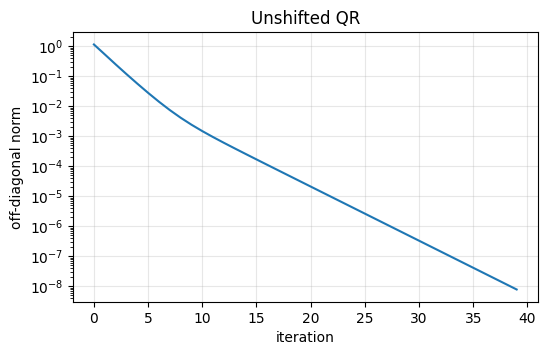

In [22]:
A=np.array([[4.,1.,1.],[1.,3.,.5],[1.,.5,2.]])
Ak=A.copy()
off=[]
for _ in range(40):
    Q,R=np.linalg.qr(Ak)
    Ak=R@Q
    off.append(np.linalg.norm(Ak-np.diag(np.diag(Ak))))
print(f'QR diagonal {np.diag(Ak)} exact {np.linalg.eigvalsh(A)}')
plt.figure(figsize=(6,3.5))
plt.semilogy(off)
plt.xlabel('iteration')
plt.ylabel('off-diagonal norm')
plt.title('Unshifted QR')
plt.grid(True,alpha=.3)
plt.show()

**ML numerics 自测**

**Q1.** unshifted QR iteration 为什么不改变特征值？

**A.** $A_k=Q_kR_k$、$A_{k+1}=R_kQ_k=Q_k^TA_kQ_k$，每步都是 similarity。

**Q2.** 它在几何上在对齐什么？

**A.** 累积 $\bar Q_k=Q_0\cdots Q_k$，把 basis 对齐到 invariant subspace，使 $A$ 在该坐标下逐步变成三角/对角。

**Q3.** 没有 shift 时什么情况会极慢？

**A.** 相邻 $|\lambda|$ 很接近、magnitude separation 差。subdiagonal 缩小可以非常慢。

**Q4.** 该看对角收敛还是该看 off-diagonal？

**A.** 看 off-diagonal / subdiagonal norm 是否在掉。对角接近还不够，没 deflation 就不算拆开。


# Lecture 29 — QR Algorithm with Shifts

### 1. Shifted QR

选择 shift $\mu_k$：

$$
A_k-\mu_kI=Q_kR_k,
$$

然后

$$
A_{k+1}=R_kQ_k+\mu_kI.
$$

仍然有

$$
A_{k+1}=Q_k^TA_kQ_k,
$$

所以 eigenvalues 仍保持不变。

### 2. 为什么 shift 加速

对于 power/inverse-type iteration，收敛速度由 eigenvalue ratios 决定。适当 shift 改变这些 ratios，使目标 eigenvalue 更快被分离。

### 3. Deflation

当某个 subdiagonal $a_{i+1,i}$ 足够小，就可以把矩阵近似拆成两个 block，分别继续做 eigen solve。现代 QR eigensolver 的效率很大程度来自 aggressive deflation + good shifts。

### 4. Engineering analogy

shift 的思想本质是“改变谱的位置，让原来困难的方向更容易被算法分辨”。这和 damping/preconditioning 虽不相同，但都在主动修改 spectral geometry。

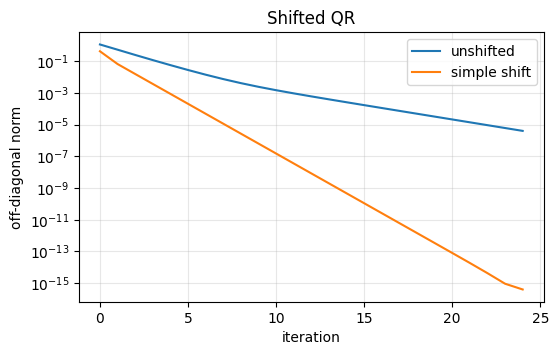

In [23]:
A=np.array([[4.,1.,1.],[1.,3.,.5],[1.,.5,2.]])
def run(A,shifted,steps=20):
    A=A.copy()
    h=[]
    for _ in range(steps):
        mu=A[-1,-1] if shifted else 0.
        Q,R=np.linalg.qr(A-mu*np.eye(3))
        A=R@Q+mu*np.eye(3)
        h.append(np.linalg.norm(A-np.diag(np.diag(A))))
    return np.array(h)
hu=run(A,False,25)
hs=run(A,True,25)
plt.figure(figsize=(6,3.5))
plt.semilogy(hu,label='unshifted')
plt.semilogy(hs,label='simple shift')
plt.legend()
plt.xlabel('iteration')
plt.ylabel('off-diagonal norm')
plt.title('Shifted QR')
plt.grid(True,alpha=.3)
plt.show()

**ML numerics 自测**

**Q1.** shifted QR 还是 similarity 吗？

**A.** 是。$A_k-\mu_k I=Q_kR_k$、$A_{k+1}=R_kQ_k+\mu_k I=Q_k^TA_kQ_k$，特征值仍不变。

**Q2.** shift 为什么加速？

**A.** 它改 eigenvalue ratio，让目标特征值更快被分离。和 power/inverse iteration 是同一类谱几何操作。

**Q3.** deflation 在省什么？

**A.** subdiagonal 足够小时把矩阵拆成两个 block 分别做。现代 QR eigensolver 的效率大量来自 aggressive deflation + 好 shift。

**Q4.** 和 damping / preconditioning 的共同点是什么？

**A.** 都在主动改 spectral geometry，让原来难分辨或难走的方向变得可算。机制不同，意图同类。


# Lecture 30 — Other Eigenvalue Algorithms

### 1. Eigen algorithms 的工程选择标准

真正重要的不是记住算法名称，而是回答：

- matrix 是否 symmetric/Hermitian？
- dense 还是 sparse/operator-only？
- 要全部 eigenvalues 还是几个？
- 要 extremal 还是 interior？
- 是否允许线性 solve？

### 2. 对 ML 最常见的 query

**Largest Hessian eigenvalue**

$$
\lambda_{\max}(H)=\max_{\Vert v\Vert=1}v^THv.
$$

用 power/Lanczos + HVP。

**Most negative curvature**

$$
\lambda_{\min}(H)<0.
$$

用 Lanczos targeting lower end。

**Spectral density**
不需要每个 eigenvalue exact；可以 Lanczos + quadrature/stochastic trace estimates。

### 3. 原则

不要 materialize 一个 $N\times N$ Hessian 只因为数学公式写的是 $H$。在 large-scale numerical linear algebra 中，operator action $v\mapsto Hv$ 才是 primitive。

**ML numerics 自测**

**Q1.** 选 eigen 算法时真正该先回答什么？

**A.** symmetric? dense 还是 sparse/operator? 全谱还是几个? extremal 还是 interior? 允不允许线性 solve?

**Q2.** ML 最常见的三个 query 各用什么？

**A.** $\lambda_{\max}(H)$：power/Lanczos+HVP。最负曲率：Lanczos 打下端。spectral density：Lanczos+quadrature，不必每个特征值都精确。

**Q3.** 为什么不要 materialize $N\times N$ Hessian？

**A.** 公式写的是 $H$，primitive 却是 $v\mapsto Hv$。large-scale 数值线性代数按 operator action 来组织。

**Q4.** 只记住算法名字有用吗？

**A.** 没用。名字要映射到上述 query 和矩阵结构，否则会选错复杂度。


# Lecture 31 — Computing the SVD

### 1. 为什么不能简单用 $A^TA$ 算 SVD

数学上

$$
A^TA=V\Sigma^2V^T.
$$

所以似乎可以先 eigendecompose $A^TA$，再开平方得到 singular values。

但若

$$
\sigma_1/\sigma_n=\kappa(A),
$$

则

$$
\kappa(A^TA)=\kappa(A)^2.
$$

小 singular value 的 relative information 会被严重损坏。

### 2. Bidiagonalization

稳定 SVD 算法先用左右 Householder transformations：

$$
A=UBV^T,
$$

其中 $B$ bidiagonal。因为左右 transformations 都 orthogonal，singular values 保持不变。

然后只需对小结构的 bidiagonal matrix 做迭代。

### 3. ML mapping

- full SVD：诊断 spectrum / rank；
- truncated/randomized SVD：compression；
- power iteration：只估 $\sigma_{\max}$。

选算法要和需要的 spectral resolution 匹配。

In [24]:
A=make_cond(40,1e10,2)
s=np.linalg.svd(A,compute_uv=False)
ev=np.linalg.eigvalsh(A.T@A)
sata=np.sqrt(np.clip(ev,0,None))[::-1]
print(f'sigma_min from SVD {s[-1]}')
print(f'sigma_min from eig(A^TA) {sata[-1]}')
print(f'relative error {abs(s[-1] - sata[-1]) / s[-1]}')

sigma_min from SVD 9.999999099842291e-11
sigma_min from eig(A^TA) 0.0
relative error 1.0


**ML numerics 自测**

**Q1.** 为什么不能先对 $A^TA$ 做特征分解再开方得 SVD？

**A.** 数学上 $A^TA=V\Sigma^2V^T$ 成立，但 $\kappa(A^TA)=\kappa(A)^2$。小 singular value 的相对信息会被平方条件数毁掉。

**Q2.** 稳定 SVD 先把 $A$ 变成什么？

**A.** 左右 Householder：$A=UBV^T$，$B$ 双对角。两侧都正交，singular values 不变，再只对这个小结构迭代。

**Q3.** full / truncated / power 各服务什么分辨率？

**A.** full SVD：诊断谱和 rank。truncated/randomized：压缩。power：只估 $\sigma_{\max}$。

**Q4.** 该按什么选算法？

**A.** 按你需要的 spectral resolution，不要默认“要奇异值就 full SVD”。


# Part VI — Iterative Methods

# Lecture 32 — Overview of Iterative Methods

### 1. Iterative method 的一般形式

对

$$
Ax=b,
$$

不一定 factorize $A$。可以构造 sequence $x_k\to x_*$。

经典 stationary splitting：

$$
A=M-N.
$$

迭代

$$
Mx_{k+1}=Nx_k+b,
$$

即

$$
x_{k+1}=Gx_k+c,
\qquad G=M^{-1}N.
$$

误差满足

$$
e_{k+1}=Ge_k.
$$

因此收敛需要

$$
\rho(G)<1.
$$

### 2. Krylov philosophy

更现代的方法不固定一个 stationary matrix $G$，而是在

$$
\mathcal K_k(A,r_0)=\mathrm{span}\{r_0,Ar_0,\ldots,A^{k-1}r_0\}
$$

中寻找最优 approximation。

### 3. ML scale

如果参数数目是千万级，显式 Hessian 不可能存。HVP 可以给你 $Hv$，于是 Krylov methods 仍然成立。

**ML numerics 自测**

**Q1.** stationary iteration 何时收敛？

**A.** $A=M-N$，$x_{k+1}=Gx_k+c$，$G=M^{-1}N$。误差 $e_{k+1}=Ge_k$，需要 $\rho(G)<1$。

**Q2.** Krylov 方法和固定 $G$ 的差别是什么？

**A.** 不固定一个 stationary $G$，而在 $\mathcal{K}_k(A,r_0)=\mathrm{span}\{r_0,Ar_0,\ldots,A^{k-1}r_0\}$ 里找逐步更优的近似。

**Q3.** 千万参数时 Hessian 怎么还能用这些方法？

**A.** 不存显式 $H$。HVP 给你 $Hv$，Krylov 仍然成立。

**Q4.** 该先问“能不能分解 $A$”，还是“能不能做 matvec”？

**A.** 大规模先问 matvec / HVP 是否便宜。能做 $Av$ 就可以迭代；分解往往根本存不下。


# Lecture 33 — The Arnoldi Iteration

### 1. Arnoldi 构造 Krylov orthonormal basis

从 $q_1=b/\Vert b\Vert$ 开始。第 $k$ 步计算

$$
v=Aq_k,
$$

然后把已有 basis components 去掉：

$$
h_{jk}=q_j^Tv,
\qquad
v\leftarrow v-h_{jk}q_j,
\quad j=1,\ldots,k.
$$

最后

$$
h_{k+1,k}=\Vert v\Vert,
\qquad
q_{k+1}=v/h_{k+1,k}.
$$

### 2. Arnoldi relation

把前 $k$ 个 basis 合成 $Q_k$：

$$
AQ_k=Q_{k+1}\bar H_k,
$$

其中 $\bar H_k$ 是 $(k+1)\times k$ upper Hessenberg。

等价地，

$$
Q_k^TAQ_k=H_k.
$$

所以巨大 operator 被压缩为小 Hessenberg projected operator。

### 3. Numerical problem

理论上 $Q_k^TQ_k=I$。floating point 下，如果新 vector 接近旧 Krylov span，Gram–Schmidt cancellation 会让 orthogonality 丢失。实际高质量 Arnoldi 往往需要 reorthogonalization。

In [25]:
def arnoldi(A,q,k):
    q=q/np.linalg.norm(q)
    n=len(q)
    Q=np.zeros((n,k+1))
    H=np.zeros((k+1,k))
    Q[:,0]=q
    for j in range(k):
        v=A@Q[:,j]
        for i in range(j+1):
            H[i,j]=Q[:,i]@v
            v-=H[i,j]*Q[:,i]
        H[j+1,j]=np.linalg.norm(v)
        if H[j+1,j]<1e-14: return Q[:,:j+1],H[:j+1,:j]
        Q[:,j+1]=v/H[j+1,j]
    return Q,H
A=rng.normal(size=(120,120))
Q,H=arnoldi(A,rng.normal(size=120),20)
print(f'Q shape {Q.shape} orthogonality {np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]))}')

Q shape (120, 21) orthogonality 1.4265591201166386e-15


**ML numerics 自测**

**Q1.** Arnoldi 在构造什么？

**A.** Krylov 空间的标准正交基底。$AQ_k=Q_{k+1}\bar H_k$，或 $Q_k^TAQ_k=H_k$：大算子被压成小 Hessenberg。

**Q2.** 最危险的数值步骤是哪一步？

**A.** 从 $Aq_k$ 里减掉旧 basis。新向量接近旧 Krylov span 时，Gram–Schmidt cancellation 让 $\Vert Q^TQ-I\Vert$ 炸掉。

**Q3.** 高质量实现通常还要多做什么？

**A.** reorthogonalization。理论 $Q_k^TQ_k=I$ 在浮点下不会自己保住。

**Q4.** ML 里 Arnoldi 的产出是完整 $Q$，还是小 $H_k$？

**A.** 通常要的是小 projected operator $H_k$（再拿 Ritz）。完整 $Q$ 只在需要 Ritz 向量时才留。


# Lecture 34 — How Arnoldi Locates Eigenvalues

### 1. Ritz pair

对 projected matrix

$$
H_k=Q_k^TAQ_k,
$$

求

$$
H_ky=\theta y.
$$

定义 Ritz vector

$$
u=Q_ky.
$$

则 $(\theta,u)$ 近似 $A$ 的 eigenpair。

### 2. Residual 有漂亮的公式

Arnoldi relation：

$$
AQ_k=Q_kH_k+h_{k+1,k}q_{k+1}e_k^T.
$$

于是

$$
Au-\theta u
=h_{k+1,k}q_{k+1}e_k^Ty.
$$

因此

$$
\Vert Au-\theta u\Vert_2
=|h_{k+1,k}|\,|e_k^Ty|.
$$

不需要回到 full matrix 做 expensive residual，就可以判断 Ritz pair 是否 converged。

### 3. ML mapping

Hessian Lanczos/Arnoldi diagnostics 中，Ritz residual 比“跑固定 20 steps 就认为 eigenvalue 准了”更 principled。

In [26]:
n=100
Q0,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.linspace(-5,20,n)
A=Q0@np.diag(ev)@Q0.T
q=rng.normal(size=n)
for k in [4,8,16,30]:
    Q,Hb=arnoldi(A,q,k)
    H=Hb[:k,:k]
    ritz=np.linalg.eigvalsh((H+H.T)/2)
    print(f'k {k} Ritz min/max {ritz[0]} {ritz[-1]}')
print(f'true min/max {ev[0]} {ev[-1]}')

k 4 Ritz min/max -3.674517751862945 18.114504831981566
k 8 Ritz min/max -4.33651197916984 19.828609393886495
k 16 Ritz min/max -4.898339977998647 19.99457037919067
k 30 Ritz min/max -4.999846274386212 19.999995560173325
true min/max -5.0 20.0


**ML numerics 自测**

**Q1.** Ritz pair $(\theta,u)$ 是怎么来的？

**A.** 对 $H_k=Q_k^TAQ_k$ 求 $H_ky=\theta y$，再 $u=Q_ky$。这是 $A$ 的近似特征对。

**Q2.** 为什么不必回到大矩阵就能判断收敛？

**A.** $Au-\theta u=h_{k+1,k}q_{k+1}e_k^Ty$，故 $\Vert Au-\theta u\Vert_2=|h_{k+1,k}|\,|e_k^Ty|$。

**Q3.** “跑固定 20 步就算 eigenvalue 准了”有什么问题？

**A.** 没有 residual 判据。Hessian Lanczos/Arnoldi 诊断应当看 Ritz residual，而不是步数迷信。

**Q4.** 该报 $\theta$ 还是该报 Ritz residual？

**A.** 两个都报。没有 residual 的 $\theta$ 不能当已经收敛的特征值用。


# Lecture 35 — GMRES

### 1. GMRES 的 optimization problem

要解 nonsymmetric

$$
Ax=b.
$$

初值 $x_0$，residual

$$
r_0=b-Ax_0,
\qquad \beta=\Vert r_0\Vert.
$$

GMRES 在 affine Krylov space

$$
x_k\in x_0+\mathcal K_k(A,r_0)
$$

中最小化 residual：

$$
x_k=\arg\min_{x\in x_0+\mathcal K_k}\Vert b-Ax\Vert_2.
$$

### 2. Arnoldi 把大问题变成小 least squares

写

$$
x_k=x_0+Q_ky.
$$

利用

$$
AQ_k=Q_{k+1}\bar H_k,
\qquad
r_0=\beta q_1=Q_{k+1}\beta e_1,
$$

得到

$$
r_k=Q_{k+1}(\beta e_1-\bar H_ky).
$$

因为 $Q_{k+1}$ orthonormal，

$$
\Vert r_k\Vert_2
=\Vert \beta e_1-\bar H_ky\Vert_2.
$$

所以每一步只需要解一个小 least-squares problem。

### 3. Polynomial view

GMRES residual 可写成

$$
r_k=p_k(A)r_0,
\qquad p_k(0)=1.
$$

于是 convergence 取决于能否找到在 $A$ spectrum/pseudospectrum 上很小的 polynomial。

### 4. 系统 tradeoff

GMRES residual norm 单调不增，但要保存整个 Arnoldi basis，memory 随 $k$ 增长。restart 降低 memory，却可能把有价值的 Krylov information 丢掉。

In [27]:
if SCIPY:
    n=120
    A=rng.normal(size=(n,n))/np.sqrt(n)+3*np.eye(n)
    xt=rng.normal(size=n)
    b=A@xt
    hist=[]
    x,info=spla.gmres(A,b,rtol=1e-10,atol=0,restart=40,callback=lambda r:hist.append(float(r)),callback_type='pr_norm')
    print(f'info {info} solution error {relerr(x, xt)} iterations {len(hist)}')
else: print(f'SciPy unavailable')

info 0 solution error 6.95596483447139e-11 iterations 20


**ML numerics 自测**

**Q1.** GMRES 每步在优化什么？

**A.** 在 $x_0+\mathcal{K}_k(A,r_0)$ 里最小化 $\Vert b-Ax\Vert_2$。residual 单调不增。

**Q2.** Arnoldi 怎样把大问题变成小 least squares？

**A.** $x_k=x_0+Q_ky$，$r_k=Q_{k+1}(\beta e_1-\bar H_ky)$。$Q$ 正交，故 $\Vert r_k\Vert_2=\Vert\beta e_1-\bar H_ky\Vert_2$。

**Q3.** 收敛由什么多项式决定？

**A.** $r_k=p_k(A)r_0$、$p_k(0)=1$。能否在 $A$ 的 spectrum / pseudospectrum 上把 $p_k$ 压小。

**Q4.** restart 的 tradeoff 是什么？

**A.** 不 restart 要存整个 Arnoldi basis，memory 随 $k$ 涨。restart 省内存，但丢掉已有 Krylov 信息，可能停滞。


# Lecture 36 — The Lanczos Iteration

### 1. Symmetry 把 Arnoldi 简化成 Lanczos

若 $A=A^T$，Arnoldi projected matrix

$$
H_k=Q_k^TAQ_k
$$

也 symmetric。但它同时是 upper Hessenberg，所以只能是 tridiagonal：

$$
T_k=
\begin{bmatrix}
\alpha_1&\beta_1\\
\beta_1&\alpha_2&\beta_2\\
&\ddots&\ddots&\ddots\\
&&\beta_{k-1}&\alpha_k
\end{bmatrix}.
$$

### 2. 三项 recurrence

$$
Aq_k=\beta_{k-1}q_{k-1}+\alpha_kq_k+\beta_kq_{k+1}.
$$

因此 ideal exact arithmetic 下无需对所有旧 basis 做 full orthogonalization。

### 3. 为什么 Hessian 特别适合 Lanczos

Hessian 是 symmetric operator。只要有 HVP $v\mapsto Hv$，就可以构造小 $T_k$，其 eigenvalues (Ritz values) 近似 Hessian spectrum extremes。

### 4. Finite precision catch

三项 recurrence 的 exact orthogonality 在 floating point 会慢慢丢失，已收敛的 Ritz direction 可能“重新出现”，产生 ghost eigenvalues。必要时要 selective/full reorthogonalization。

In [28]:
def lanczos(A,q,k):
    n=len(q)
    q=q/np.linalg.norm(q)
    Q=np.zeros((n,k))
    alpha=np.zeros(k)
    beta=np.zeros(k-1)
    qprev=np.zeros(n)
    b=0.
    for j in range(k):
        Q[:,j]=q
        z=A@q
        if j>0: z-=b*qprev
        a=q@z
        z-=a*q
        z-=Q[:,:j+1]@(Q[:,:j+1].T@z)
        alpha[j]=a
        if j<k-1:
            b=np.linalg.norm(z)
            beta[j]=b
            if b<1e-14: break
            qprev=q
            q=z/b
    T=np.diag(alpha)+np.diag(beta,1)+np.diag(beta,-1)
    return Q,T
n=180
Q0,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.geomspace(.01,100,n)
A=Q0@np.diag(ev)@Q0.T
Qk,T=lanczos(A,rng.normal(size=n),30)
r=np.linalg.eigvalsh(T)
print(f'Ritz min/max {r[0]} {r[-1]} true {ev[0]} {ev[-1]}')

Ritz min/max 0.038988058445983055 100.0 true 0.01 100.0


**ML numerics 自测**

**Q1.** 为什么对称时 Arnoldi 变成 Lanczos？

**A.** $A=A^T$ 则 $H_k=Q_k^TAQ_k$ 又对称又 Hessenberg，只能是三对角 $T_k$。于是有三项递推 $Aq_k=\beta_{k-1}q_{k-1}+\alpha_k q_k+\beta_k q_{k+1}$。

**Q2.** exact arithmetic 下为什么不必对全部旧 basis 正交化？

**A.** 三项递推已经隐含与更早向量正交。这是对称带来的结构，不是实现偷懒。

**Q3.** 浮点下会出现什么假象？

**A.** orthogonality 慢慢丢，已收敛的 Ritz 方向会“回来”，产生 ghost eigenvalues。需要 selective/full reorthogonalization。

**Q4.** 为何 Hessian 特别适合 Lanczos？

**A.** Hessian 对称，又有 HVP。小 $T_k$ 的特征值就能近似谱的两端。


# Lecture 37 — From Lanczos to Gauss Quadrature

### 1. 从 matrix function 到 spectral measure

若 $A=A^T=Q\Lambda Q^T$，则

$$
v^Tf(A)v
=\sum_i (q_i^Tv)^2 f(\lambda_i).
$$

这可以看成关于 eigenvalue spectral measure 的积分：

$$
v^Tf(A)v=\int f(\lambda)\,d\mu_v(\lambda).
$$

### 2. Lanczos quadrature

运行 $k$ 步 Lanczos 得到 $T_k$。一个关键近似是

$$
v^Tf(A)v
\approx
\Vert v\Vert^2 e_1^Tf(T_k)e_1.
$$

如果

$$
T_k=S\Theta S^T,
$$

则

$$
e_1^Tf(T_k)e_1
=\sum_j S_{1j}^2 f(\theta_j),
$$

正是一个 Gauss quadrature rule。

### 3. ML applications

- $f(\lambda)=\lambda$：trace/curvature moments；
- $f(\lambda)=1/\lambda$：inverse curvature quadratic forms；
- $f(\lambda)=\log\lambda$：logdet-like quantities；
- kernelized $f$：spectral density。

结合 random probe $v$ 就得到 stochastic Lanczos quadrature (SLQ) 的基础。

In [29]:
n=140
Q0,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.geomspace(.2,30,n)
A=Q0@np.diag(ev)@Q0.T
v=rng.normal(size=n)
nv=np.linalg.norm(v)
Qk,T=lanczos(A,v/nv,30)
th,S=np.linalg.eigh(T)
approx=nv**2*np.sum((S[0,:]**2)/th)
exact=v@np.linalg.solve(A,v)
print(f'exact {exact} Lanczos quadrature {approx} relative error {abs(approx - exact) / abs(exact)}')

exact 103.53147604786616 Lanczos quadrature 103.52635405646723 relative error 4.947279411498997e-05


**ML numerics 自测**

**Q1.** $v^Tf(A)v$ 为什么是谱上的积分？

**A.** $A=Q\Lambda Q^T$ 时 $v^Tf(A)v=\sum_i(q_i^Tv)^2 f(\lambda_i)=\int f(\lambda)\,d\mu_v(\lambda)$。

**Q2.** Lanczos quadrature 的公式是什么？

**A.** $v^Tf(A)v\approx\Vert v\Vert^2 e_1^T f(T_k)e_1$。$T_k=S\Theta S^T$ 后就是权 $S_{1j}^2$、节点 $\theta_j$ 的 Gauss 求积。

**Q3.** ML 里 $f(\lambda)$ 常见取什么？

**A.** $\lambda$：trace/曲率矩；$1/\lambda$：inverse curvature；$\\log\lambda$：logdet-like；再加随机 $v$ 就是 SLQ。

**Q4.** 这还需要每个特征值都算准吗？

**A.** 不需要。要的是对某个 $f$ 的谱积分，不是完整 eigendecomposition。


# Lecture 38 — Conjugate Gradients

### 1. CG 是 quadratic optimization

对 SPD $A$，定义

$$
\phi(x)=\frac12x^TAx-b^Tx.
$$

梯度

$$
\nabla\phi(x)=Ax-b=-r.
$$

stationary point 就是

$$
Ax=b.
$$

### 2. A-conjugate directions

CG 构造搜索方向 $p_i$，满足

$$
p_i^TAp_j=0\quad(i\neq j).
$$

这比 Euclidean orthogonality 更匹配 quadratic geometry。

### 3. Krylov optimality

第 $k$ 步解满足

$$
x_k\in x_0+\mathcal K_k(A,r_0)
$$

并最小化 A-norm error：

$$
\Vert x_*-x_k\Vert_A
=\min_{x\in x_0+\mathcal K_k}\Vert x_*-x\Vert_A,
$$

其中

$$
\Vert e\Vert_A=\sqrt{e^TAe}.
$$

### 4. Condition-number convergence bound

经典 bound：

$$
\frac{\Vert e_k\Vert_A}{\Vert e_0\Vert_A}
\le
2\left(
\frac{\sqrt\kappa-1}{\sqrt\kappa+1}
\right)^k.
$$

这个 bound 解释为什么 $\kappa$ 大时 CG 慢，但实际 convergence 还受 eigenvalue clustering 影响，往往比 worst-case bound 更好。

### 5. Optimization mapping

damped Newton/Gauss–Newton：

$$
(H+\lambda I)p=-g
$$

如果可用 HVP，就可以 CG matrix-free solve。

iterations 180 solution error 0.09533671182751831


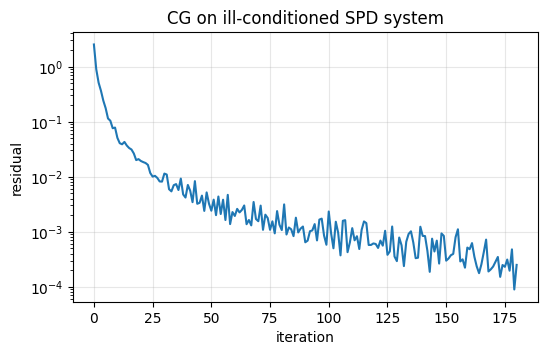

In [30]:
def cg(A,b,maxiter=250,tol=1e-10):
    x=np.zeros_like(b)
    r=b-A@x
    p=r.copy()
    rr=r@r
    h=[np.sqrt(rr)]
    for _ in range(maxiter):
        Ap=A@p
        a=rr/(p@Ap)
        x+=a*p
        r-=a*Ap
        rrn=r@r
        h.append(np.sqrt(rrn))
        if np.sqrt(rrn)<tol: break
        p=r+(rrn/rr)*p
        rr=rrn
    return x,np.array(h)
n=140
Q0,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.geomspace(1,1e-5,n)
A=Q0@np.diag(ev)@Q0.T
xt=rng.normal(size=n)
b=A@xt
x,h=cg(A,b,180)
print(f'iterations {len(h) - 1} solution error {relerr(x, xt)}')
plt.figure(figsize=(6,3.5))
plt.semilogy(h)
plt.xlabel('iteration')
plt.ylabel('residual')
plt.title('CG on ill-conditioned SPD system')
plt.grid(True,alpha=.3)
plt.show()

**ML numerics 自测**

**Q1.** CG 对应的优化问题是什么？

**A.** SPD 上 $\phi(x)=\frac12 x^TAx-b^Tx$。$\nabla\phi=Ax-b$，驻点就是 $Ax=b$。

**Q2.** 它在哪个范数下最优？

**A.** 第 $k$ 步在 $x_0+\mathcal{K}_k$ 里最小化 $\Vert x_*-x\Vert_A$，$\Vert e\Vert_A=\sqrt{e^TAe}$。方向满足 $p_i^TAp_j=0$。

**Q3.** 经典 bound 和 $\kappa$ 的关系？

**A.** $\Vert e_k\Vert_A/\Vert e_0\Vert_A\le 2((\sqrt{\kappa}-1)/(\sqrt{\kappa}+1))^k$。$\kappa$ 大则慢；实际还受 eigenvalue clustering 影响，常好于 worst-case。

**Q4.** damped Newton 怎么接上 CG？

**A.** $(H+\lambda I)p=-g$。有 HVP 就可以 matrix-free CG，不必存 $H$。


# Lecture 39 — Biorthogonalization Methods

### 1. 为什么 nonsymmetric matrix 没有 Lanczos 的简单正交结构

对 general $A$，右 Krylov space 用 $A$，左 Krylov space 用 $A^T$：

$$
\mathcal K_k(A,v_1),
\qquad
\mathcal K_k(A^T,w_1).
$$

构造两组 basis $V_k,W_k$，满足 biorthogonality：

$$
W_k^TV_k=I.
$$

### 2. 两侧 projection

可以得到类似

$$
AV_k=V_kT_k+\cdots,
\qquad
A^TW_k=W_kT_k^T+\cdots
$$

的短 recurrence。

### 3. Benefit / cost

优点：不像 GMRES 那样必须保存 growing orthonormal basis，memory 低。

代价：

- 不再最小化 2-norm residual；
- denominator 可能接近 0，引发 breakdown；
- residual 常常 nonmonotone。

BiCGSTAB 是把 BiCG residual 行为“平滑化”的实用变体之一。

In [31]:
if SCIPY:
    n=150
    A=rng.normal(size=(n,n))/np.sqrt(n)+2.5*np.eye(n)
    xt=rng.normal(size=n)
    b=A@xt
    hist=[]
    x,info=spla.bicgstab(A,b,rtol=1e-10,atol=0,maxiter=500,callback=lambda xk:hist.append(np.linalg.norm(b-A@xk)))
    print(f'info {info} solution error {relerr(x, xt)} iterations {len(hist)}')
else: print(f'SciPy unavailable')

info 0 solution error 3.862140021869542e-11 iterations 13


**ML numerics 自测**

**Q1.** nonsymmetric 时为什么要两套 Krylov？

**A.** 右空间用 $A$，左空间用 $A^T$。构造 $V_k,W_k$ 使 $W_k^TV_k=I$（biorthogonality），才能维持短递推。

**Q2.** 相对 GMRES 的收益和代价是什么？

**A.** 收益：不必存增长的正交基底，memory 低。代价：不再最小化 2-norm residual；分母可接近 0 而 breakdown；residual 常非单调。

**Q3.** BiCGSTAB 在修什么？

**A.** 把 BiCG 那种抖的 residual 行为平滑化，是更常用的实用变体。

**Q4.** 什么时候不该用这类方法？

**A.** 你需要单调、可解释的 $\Vert r\Vert_2$ 下降，或 breakdown 不可接受时，应回到 GMRES（或加更好的 preconditioner）。


# Lecture 40 — Preconditioning

### 1. Preconditioning 的目标

原问题

$$
Ax=b.
$$

找一个容易 invert 的 $M\approx A$。

**Left preconditioning**：

$$
M^{-1}Ax=M^{-1}b.
$$

**Right preconditioning**：

$$
AM^{-1}y=b,
\qquad x=M^{-1}y.
$$

### 2. 为什么会加速

对 SPD/CG，理想上希望

$$
\kappa(M^{-1}A)\ll\kappa(A),
$$

更进一步，希望 eigenvalues clustered around 1。

如果

$$
M=A,
$$

当然一步解决，但 preconditioner 本身就和原问题一样贵。实际是在“每步成本”和“iteration reduction”之间 trade off。

### 3. Jacobi example

$$
M=\operatorname{diag}(A).
$$

它只做 coordinate-wise scaling，廉价但只能修复一部分 anisotropy。

### 4. Optimization mapping

一个 badly scaled quadratic：

$$
\frac12x^THx
$$

在 Euclidean coordinates 中是窄长 valley。preconditioning 相当于换坐标，把 valley 尽量变圆。

这和 Adam 类 adaptive scaling 有概念联系，但不能简单把 Adam 等同于 classical preconditioned CG。

CG iters 250 PCG iters 188


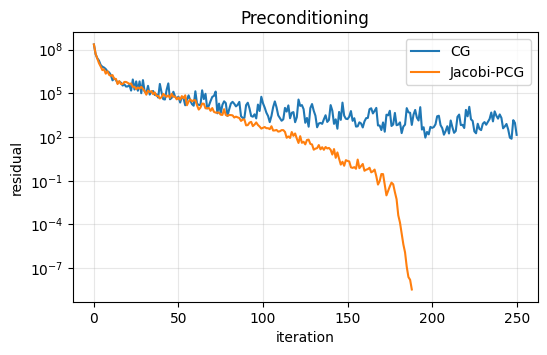

In [32]:
def pcg_diag(A,b,maxiter=250,tol=1e-8):
    Mi=1/np.diag(A)
    x=np.zeros_like(b)
    r=b-A@x
    z=Mi*r
    p=z.copy()
    rz=r@z
    h=[np.linalg.norm(r)]
    for _ in range(maxiter):
        Ap=A@p
        a=rz/(p@Ap)
        x+=a*p
        r-=a*Ap
        h.append(np.linalg.norm(r))
        if h[-1]<tol: break
        z=Mi*r
        rzn=r@z
        p=z+(rzn/rz)*p
        rz=rzn
    return x,np.array(h)
n=120
R=rng.normal(size=(n,n))
B=R.T@R+.5*np.eye(n)
s=np.geomspace(1e-3,1e3,n)
D=np.diag(s)
A=D@B@D
xt=rng.normal(size=n)
b=A@xt
_,h1=cg(A,b,250,1e-8)
_,h2=pcg_diag(A,b,250,1e-8)
print(f'CG iters {len(h1) - 1} PCG iters {len(h2) - 1}')
plt.figure(figsize=(6,3.5))
plt.semilogy(h1,label='CG')
plt.semilogy(h2,label='Jacobi-PCG')
plt.legend()
plt.xlabel('iteration')
plt.ylabel('residual')
plt.title('Preconditioning')
plt.grid(True,alpha=.3)
plt.show()

In [33]:
def qint8(x,axis=None):
    if axis is None:
        a=np.max(np.abs(x))
        s=a/127 if a>0 else 1.
    else:
        a=np.max(np.abs(x),axis=axis,keepdims=True)
        s=np.where(a>0,a/127,1.)
    return np.clip(np.round(x/s),-127,127)*s
X=rng.normal(size=(4096,64))
X[:,7]*=35
Xt=qint8(X)
Xc=qint8(X,0)
print(f'per-tensor error {relerr(Xt, X)}')
print(f'per-channel error {relerr(Xc, X)}')

per-tensor error 0.061033007086233215
per-channel error 0.007904102358807293


In [34]:
dims=[64,64,64,64,32]
Ws=[rng.normal(scale=.08,size=(dims[i+1],dims[i])) for i in range(len(dims)-1)]
u=rng.normal(size=64)
u/=np.linalg.norm(u)
v=rng.normal(size=64)
v/=np.linalg.norm(v)
Ws[2]+=8*np.outer(u,v)
def fwd(Ws,x):
    for W in Ws: x=W@x
    return x
x=rng.normal(size=64)
y=fwd(Ws,x)
print(f'layer  local_weight_error  final_output_error')
for i in range(len(Ws)):
    Wq=[w.copy() for w in Ws]
    Wq[i]=Wq[i].astype(np.float16).astype(float)
    yq=fwd(Wq,x)
    print(f'{i} {relerr(Wq[i], Ws[i])} {relerr(yq, y)}')

layer  local_weight_error  final_output_error
0 0.00020199560567719108 9.128981963807791e-05
1 0.00020828373065435275 0.00013344761242405797
2 0.00020861254641664975 0.0001224397069047388
3 0.0002092168252893803 0.00019933537150459188


**ML numerics 自测**

**Q1.** preconditioning 在改哪个问题？

**A.** 找便宜的 $M\approx A$。左：$M^{-1}Ax=M^{-1}b$；右：$AM^{-1}y=b$、$x=M^{-1}y$。目标是 $\kappa(M^{-1}A)\ll\kappa(A)$，最好特征值聚在 1 附近。

**Q2.** 为什么 $M=A$ 不是合法答案？

**A.** 一步就解完，但 preconditioner 和原问题一样贵。实际是在每步成本和迭代次数之间折中。

**Q3.** Jacobi $M=\mathrm{diag}(A)$ 能修什么、不能修什么？

**A.** 只做坐标缩放，廉价，只能修一部分 anisotropy，不能修掉真正的病态耦合。

**Q4.** 和 Adam 能画等号吗？

**A.** 概念上都在改坐标、把窄长 valley 变圆一些。但不能把 Adam 等同于 classical preconditioned CG。


# Synthesis A — Training Numerics: 从 layer spectrum 到 checkpoint sensitivity

对深度网络局部线性化：

$$
\delta h_{\ell+1}=J_\ell\delta h_\ell+\epsilon_\ell,
$$

其中 $\epsilon_\ell$ 可以代表 rounding、quantization、optimizer-induced perturbation 或 upstream representation drift。

展开到输出：

$$
\delta h_L
\approx
\sum_{\ell=0}^{L-1}
J_{L-1}J_{L-2}\cdots J_{\ell+1}\epsilon_\ell.
$$

因此某层是否“load bearing”取决于两件事：

1. 它产生多大的 local perturbation；
2. 该 perturbation 之后会经过多大的 downstream gain。

这解释了为什么：

- 最大 weight diff 的 layer 不一定造成最大 behavior diff；
- local FP16 error 很小的 layer 也可能是 precision-sensitive layer；
- 高 $\sigma_{\max}$ / low stable-rank direction 可能成为 variance carrier。

一个 principled profiler 应同时记录：

$$
\sigma_{\max}(W),\quad
\Vert W\Vert_F,\quad
r_{stable},\quad
\Vert \nabla W\Vert,\quad
\Vert \Delta W\Vert/\Vert W\Vert,
$$

以及 downstream task perturbation。

# Synthesis B — Optimization Numerics: curvature, damping, CG, preconditioning

局部二次模型：

$$
L(\theta+p)
\approx
L(\theta)+g^Tp+\frac12p^THp.
$$

Newton step：

$$
Hp=-g.
$$

如果 $H$ 有极小 positive eigenvalues，step 沿这些方向非常大：

$$
p_i=-\frac{g_i}{\lambda_i}.
$$

这既是 optimization sensitivity，也是 numerical sensitivity。

Damping：

$$
(H+\lambda I)p=-g
$$

把

$$
\frac1{\lambda_i}
\quad\to\quad
\frac1{\lambda_i+\lambda}.
$$

它不是“为了让 Cholesky 不报错而打补丁”，而是在明确限制 weak-curvature directions 的 inverse gain。

如果 $H$ 太大无法 factorize：

- HVP + Lanczos：看 spectrum；
- HVP + CG：solve；
- preconditioner：改善 geometry。

这三者是同一套 Krylov / spectral framework 的不同用途。

# Synthesis C — Deployment Numerics: precision allocation 应该怎样 principled

设 reference operator $f$ 在某一局部输入 $x$ 附近：

$$
f(x+\delta x)\approx f(x)+J\delta x.
$$

低精度 kernel 产生 local error $\epsilon$，则 downstream error 近似

$$
\delta y\approx J\epsilon.
$$

因此 precision decision 不能只按 operator name：

> `softmax always FP32`, `matmul always BF16`

这些只能作为经验起点。真正的 decision variable 应该是

$$
\underbrace{\Vert \epsilon\Vert}_{\text{local numeric error}}
\times
\underbrace{\Vert J\Vert}_{\text{downstream sensitivity}}
$$

以及 task-level error budget。

特别高风险的结构：

### Gram / normal-equation construction

$$
G=A^TA
$$

不仅可能 overflow/accumulate error，还会把 conditioning 平方。

### Cholesky
small pivot 对 low precision 极敏感。

### Quantization outliers
per-tensor scale 被一个 channel 控制时，其余 directions resolution 下降。

### Non-normal high-gain layer
即使 eigenvalues 看起来稳定，$\sigma_{\max}$ 仍可能非常大。

这也是为什么 deployment parity 最终是 numerical linear algebra 问题，而不只是“比较两个输出 tensor”。

# Suggested Projects / 真正把这本书变成 ML numerics 工具

## Project 1 — Spectral training monitor
每 N steps 对关键 layer 做 power iteration：

$$
\sigma_{\max}(W_\ell).
$$

同时记录 stable rank、WUR、gradient norm，观察在 divergence/checkpoint variance 前后谁先变化。

## Project 2 — Representation subspace stability
对 activation matrix $X$ 做 QR/SVD，比较 checkpoint 的 projector：

$$
P=QQ^T.
$$

避免把 arbitrary basis rotation 误判成 representation drift。

## Project 3 — Hessian matrix-free diagnostics
用 HVP 实现：

1. power iteration；
2. Lanczos Ritz spectrum；
3. CG solve $(H+\lambda I)p=-g$；
4. sweep $\lambda$ 看 convergence 与 step norm。

## Project 4 — Precision sensitivity harness
逐层注入 BF16/FP16/INT8 perturbation：

$$
\epsilon_\ell=\hat h_\ell-h_\ell.
$$

同时比较 local error 与 final task error，建立 mixed-precision allocation。

## Project 5 — Solver torture test
构造控制以下变量的 matrix family：

- $\kappa$；
- $\lambda_{min}$；
- non-normality；
- scaling range；
- pivot growth；
- rank deficiency。

验证 custom/compiled solver 的 residual、forward error、backward error，而不是只做 random smoke test。